Dataset housing cargado desde el laboratorio 07.
Filas: 20640, columnas totales: 10
Columnas numéricas usadas como X: 8
Target: median_house_value discretizado en clases para clasificación.

--- Comparación datos sin procesar vs. procesados ---
      estado  filas  caracteristicas  faltantes  media_global  desv_std_global
Sin procesar  20640                8          0  6.307738e+02              NaN
   Procesado  20640                8          0  4.990156e-09              1.0

--- Muestra rápida de columnas originales ---
 longitude  latitude  housing_median_age  total_rooms  total_bedrooms  population  households  median_income  median_house_value ocean_proximity
   -122.23     37.88                41.0        880.0           129.0       322.0       126.0         8.3252            452600.0        NEAR BAY
   -122.22     37.86                21.0       7099.0          1106.0      2401.0      1138.0         8.3014            358500.0        NEAR BAY
   -122.24     37.85                

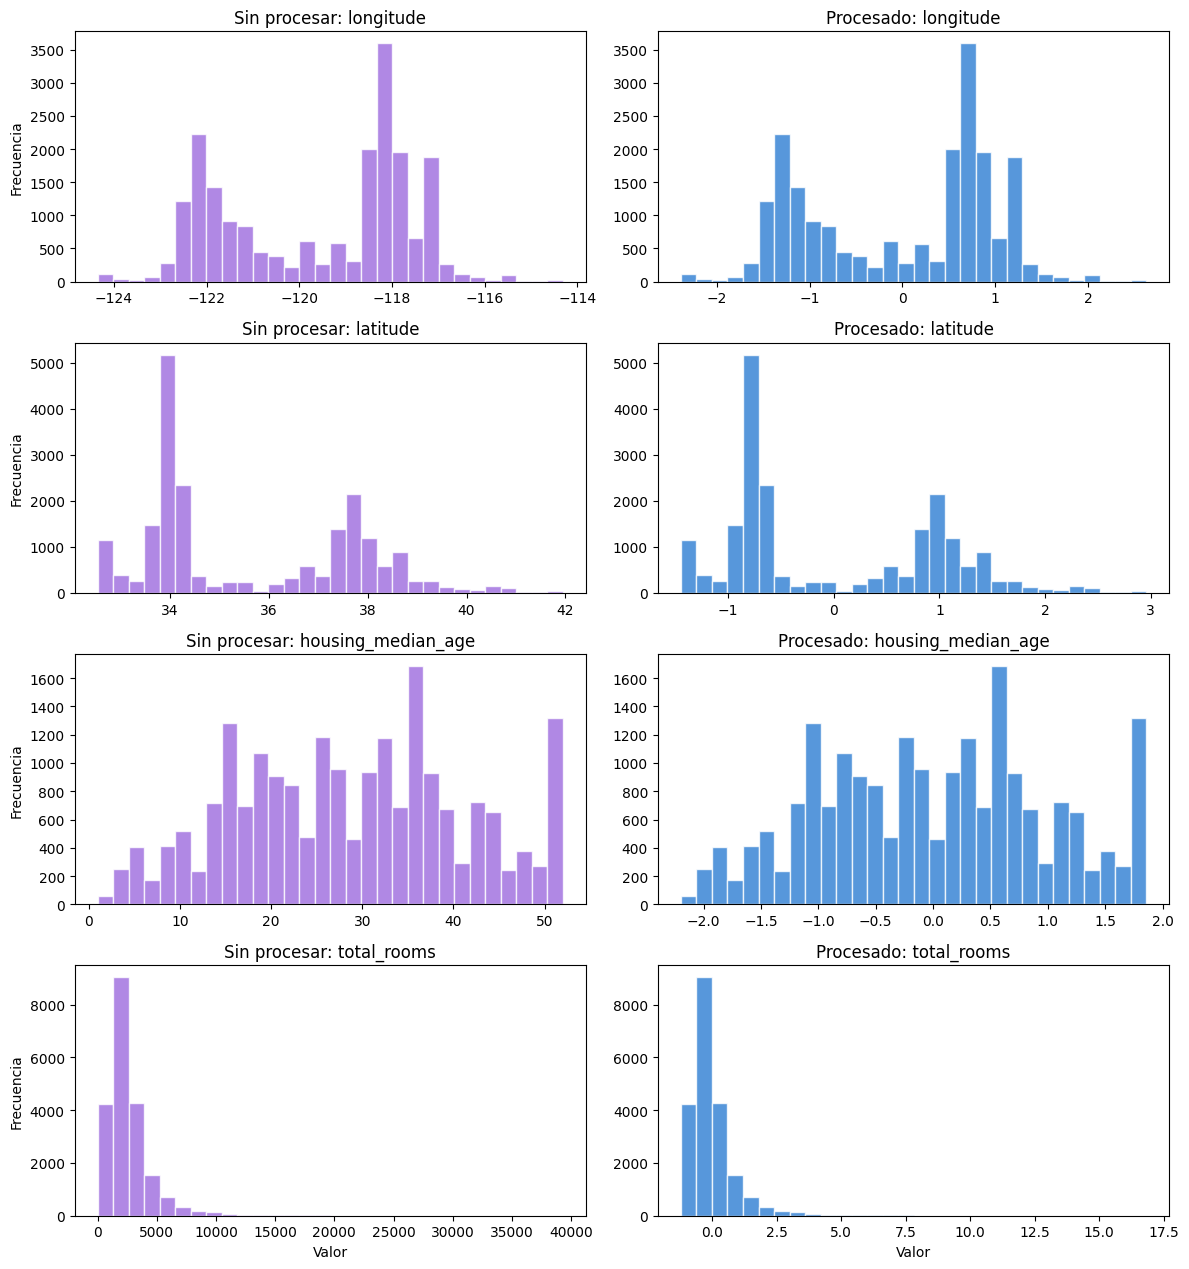


Dataset: 8 características -> reduciendo a 3 dimensiones
Train: 16512 muestras, Test: 4128 muestras
Distribución de clases: [6884 6876 6880]

--- Entrenando autoencoder híbrido (global + local) ---
Epoch 001/80 - loss: 0.294322 - reconstruction: 0.227186 - local: 0.447572
Epoch 002/80 - loss: 0.170121 - reconstruction: 0.146313 - local: 0.158717
Epoch 003/80 - loss: 0.141320 - reconstruction: 0.126391 - local: 0.099520
Epoch 004/80 - loss: 0.126251 - reconstruction: 0.111779 - local: 0.096484
Epoch 005/80 - loss: 0.108446 - reconstruction: 0.093346 - local: 0.100663
Epoch 006/80 - loss: 0.092351 - reconstruction: 0.077452 - local: 0.099332
Epoch 007/80 - loss: 0.087742 - reconstruction: 0.073328 - local: 0.096093
Epoch 008/80 - loss: 0.083827 - reconstruction: 0.070399 - local: 0.089523
Epoch 009/80 - loss: 0.080252 - reconstruction: 0.067165 - local: 0.087249
Epoch 010/80 - loss: 0.079519 - reconstruction: 0.066911 - local: 0.084052
Epoch 011/80 - loss: 0.077198 - reconstruction: 0.0

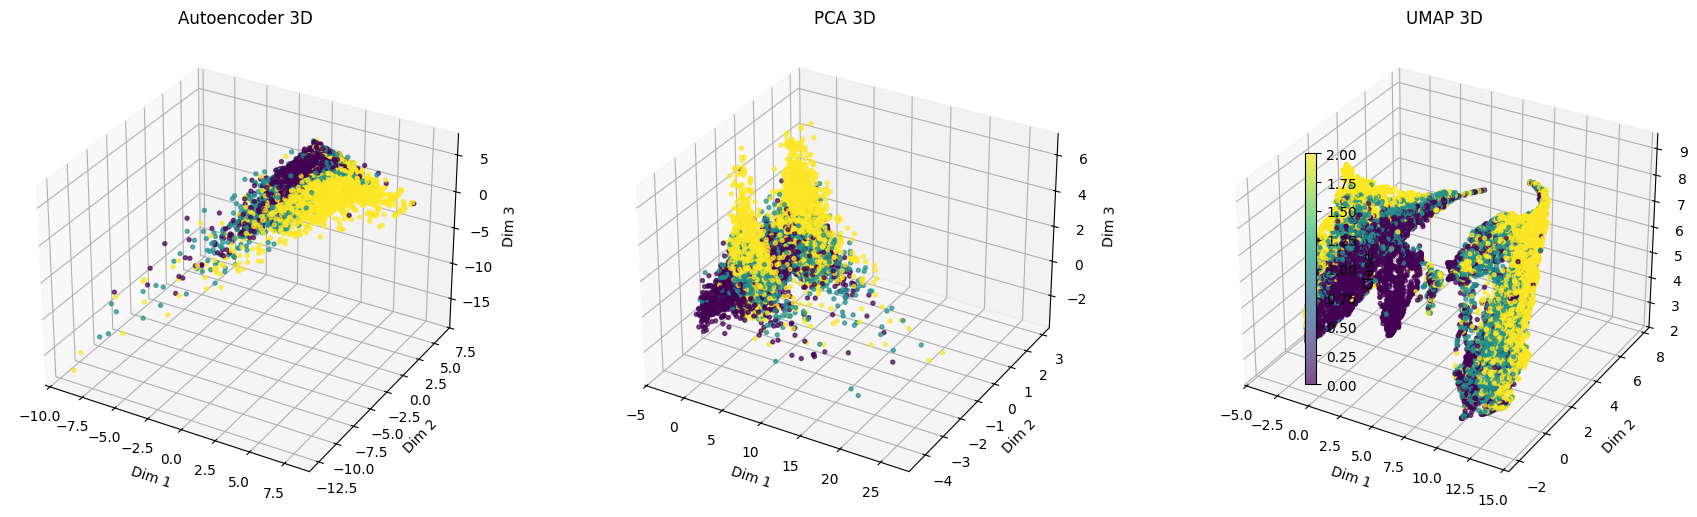


--- Benchmark: Pipeline estilo laboratorio 07 ---
Test Accuracy (Lab 07 style): 0.7951
Test F1-Score (Lab 07 style):   0.7961

--- Comparación directa de pipelines ---
                pipeline  accuracy     f1  dimensiones
  Actual: autoencoder 3D    0.6361 0.6395            3
          Actual: PCA 3D    0.6303    NaN            3
         Actual: UMAP 3D    0.6611 0.6640            3
            Lab 07 style    0.7951 0.7961           13
Actual: datos originales    0.7902    NaN            8


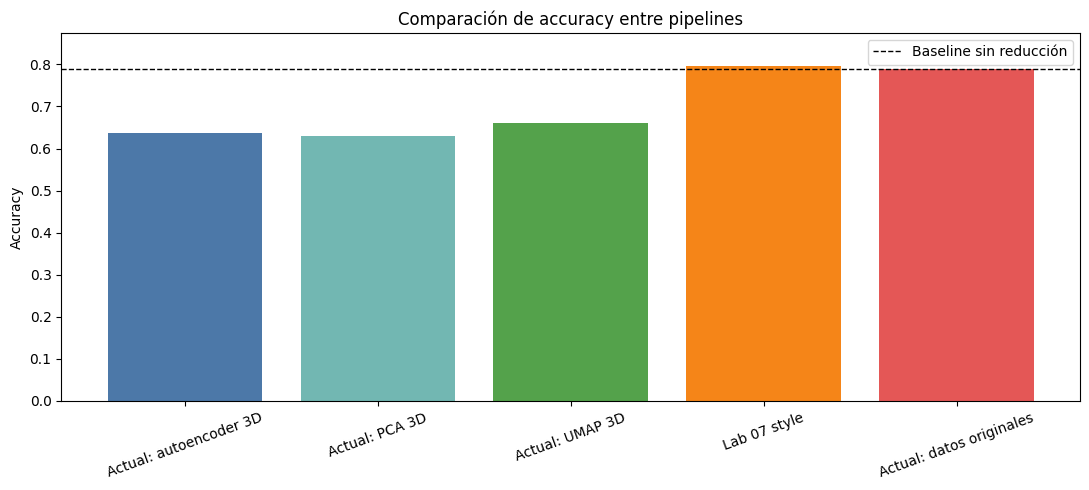


--- Búsqueda de la máxima reducción coherente con PCA ---
 dimensiones  accuracy  mse_reconstruccion  varianza_explicada  coherente
           1    0.3576              0.5211              0.4756      False
           2    0.4915              0.2818              0.7204      False
           3    0.6296              0.1498              0.8585      False
           4    0.6839              0.0487              0.9646      False
           5    0.7037              0.0201              0.9813      False
           6    0.7553              0.0095              0.9917       True
           7    0.7752              0.0036              0.9978       True
           8    0.7752              0.0000              1.0000       True

Máxima reducción coherente: 8 -> 6 dimensiones (25.0% de reducción).


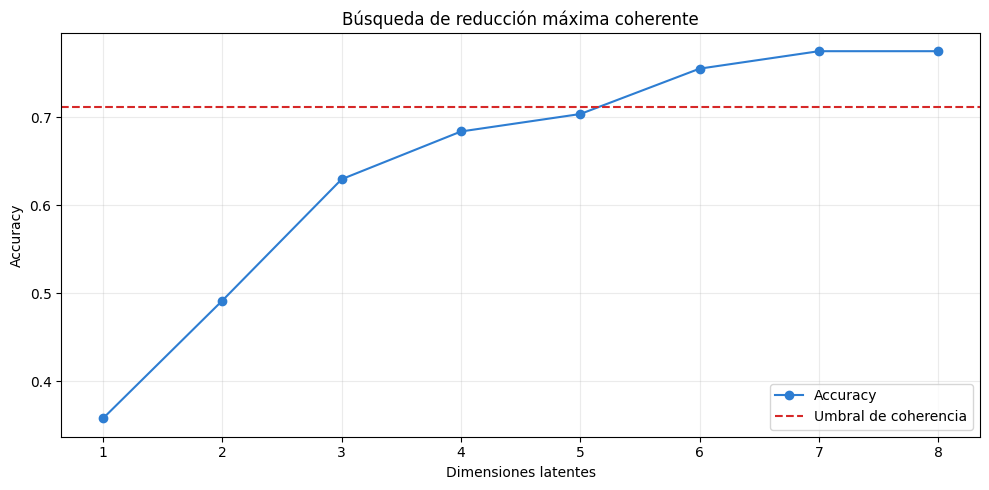


Pipeline completado. El embedding conserva estructura global y local de forma explícita.


In [ ]:
# =====================================================
# PIPELINE COMPLETO: Autoencoder híbrido + ML
# Reducción de dimensionalidad con pérdida global + local
# Ejemplo con housing del laboratorio 07
# =====================================================

import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from umap import UMAP

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

# -----------------------------------------------------
# 1. CARGA TU DATASET (X, y)
# -----------------------------------------------------
# Ejemplo basado en el housing usado en el laboratorio 07.
# Se usa median_house_value como target y se discretiza en clases.
housing_url = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"
try:
    df = pd.read_csv(housing_url)
    target_column = "median_house_value"
    numeric_df = df.select_dtypes(include=[np.number]).copy()

    if target_column not in numeric_df.columns:
        raise ValueError(f"No se encontró la columna objetivo {target_column}.")

    y_raw = numeric_df[target_column].copy()
    X = numeric_df.drop(columns=[target_column])
    X = X.fillna(X.median(numeric_only=True))
    y = pd.qcut(y_raw, q=3, labels=False, duplicates="drop").to_numpy()

    print("Dataset housing cargado desde el laboratorio 07.")
    print(f"Filas: {df.shape[0]}, columnas totales: {df.shape[1]}")
    print(f"Columnas numéricas usadas como X: {X.shape[1]}")
    print("Target: median_house_value discretizado en clases para clasificación.")
except Exception as exc:
    from sklearn.datasets import make_classification

    print(f"No fue posible cargar housing ({exc}). Usando dataset sintético de respaldo.")
    X, y = make_classification(
        n_samples=2000,
        n_features=100,
        n_informative=50,
        n_redundant=30,
        n_classes=3,
        random_state=SEED,
    )
    df = pd.DataFrame(X)
    target_column = None

# Comparación rápida: datos crudos vs. datos listos
if isinstance(X, pd.DataFrame):
    X_raw_preview = X.copy()
else:
    X_raw_preview = pd.DataFrame(X)

raw_values_array = X_raw_preview.to_numpy(dtype=np.float32, copy=True)
raw_missing = int(np.isnan(raw_values_array).sum()) if np.issubdtype(raw_values_array.dtype, np.number) else 0
raw_summary = pd.DataFrame(
    {
        "estado": ["Sin procesar"],
        "filas": [X_raw_preview.shape[0]],
        "caracteristicas": [X_raw_preview.shape[1]],
        "faltantes": [raw_missing],
        "media_global": [float(np.nanmean(raw_values_array))],
    }
)

# -----------------------------------------------------
# 2. PREPROCESAMIENTO
# -----------------------------------------------------
def prepare_features(data):
    """Convierte X en una matriz numérica 2D y rellena NaN si existen."""
    if hasattr(data, "select_dtypes"):
        data = data.select_dtypes(include=[np.number]).to_numpy()
    else:
        data = np.asarray(data)

    if data.ndim != 2:
        raise ValueError("X debe ser una matriz 2D numérica.")

    data = data.astype(np.float32)

    if np.isnan(data).any():
        col_means = np.nanmean(data, axis=0)
        col_means = np.where(np.isnan(col_means), 0.0, col_means)
        nan_rows, nan_cols = np.where(np.isnan(data))
        data[nan_rows, nan_cols] = col_means[nan_cols]

    return data


def tanh_grad(activations):
    return 1.0 - np.square(activations)


X = prepare_features(X)
y = np.asarray(y).ravel()

if y.dtype.kind in {"O", "U", "S"}:
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

processed_summary = pd.DataFrame(
    {
        "estado": ["Procesado"],
        "filas": [X_scaled.shape[0]],
        "caracteristicas": [X_scaled.shape[1]],
        "faltantes": [int(np.isnan(X_scaled).sum())],
        "media_global": [float(np.mean(X_scaled))],
        "desv_std_global": [float(np.std(X_scaled))],
    }
)

comparison_df = pd.concat(
    [
        raw_summary.assign(desv_std_global=np.nan),
        processed_summary,
    ],
    ignore_index=True,
)

print("\n--- Comparación datos sin procesar vs. procesados ---")
print(comparison_df.to_string(index=False))

print("\n--- Muestra rápida de columnas originales ---")
print(df.head(3).to_string(index=False))

print("\n--- Muestra rápida de datos procesados (primeras 3 filas de X_scaled) ---")
print(pd.DataFrame(X_scaled[:3, :], columns=[f"x{i+1}" for i in range(X_scaled.shape[1])]).to_string(index=False))

comparison_features = list(X_raw_preview.columns[:4])
if len(comparison_features) > 0:
    fig, axes = plt.subplots(len(comparison_features), 2, figsize=(12, 3.2 * len(comparison_features)))
    if len(comparison_features) == 1:
        axes = np.array([axes])

    for row_index, feature_name in enumerate(comparison_features):
        raw_values = pd.to_numeric(X_raw_preview[feature_name], errors="coerce").to_numpy(dtype=np.float32)
        processed_values = X_scaled[:, row_index]

        axes[row_index, 0].hist(raw_values[~np.isnan(raw_values)], bins=30, color="#9c6ade", alpha=0.8, edgecolor="white")
        axes[row_index, 0].set_title(f"Sin procesar: {feature_name}")
        axes[row_index, 0].set_ylabel("Frecuencia")

        axes[row_index, 1].hist(processed_values, bins=30, color="#2d7dd2", alpha=0.8, edgecolor="white")
        axes[row_index, 1].set_title(f"Procesado: {feature_name}")

    for axis in axes[-1, :]:
        axis.set_xlabel("Valor")

    plt.tight_layout()
    plt.show()

stratify = y if np.unique(y).size > 1 else None
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=stratify,
)

print(f"\nDataset: {X_train.shape[1]} características -> reduciendo a 3 dimensiones")
print(f"Train: {X_train.shape[0]} muestras, Test: {X_test.shape[0]} muestras")
print(f"Distribución de clases: {np.bincount(y.astype(int))}")

# -----------------------------------------------------
# 3. AUTOENCODER HÍBRIDO (GLOBAL + LOCAL)
# -----------------------------------------------------
class HybridAutoencoder:
    def __init__(
        self,
        input_dim,
        encoding_dim=3,
        lambda_local=0.1,
        hidden_units=(128, 64),
        learning_rate=1e-3,
        seed=42,
    ):
        self.input_dim = input_dim
        self.encoding_dim = encoding_dim
        self.lambda_local = lambda_local
        self.hidden_units = hidden_units
        self.learning_rate = learning_rate
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self.params = self._initialize_parameters()
        self.optimizer_state = self._initialize_optimizer_state()
        self.optimizer_step = 0
        self.history = {"loss": [], "reconstruction_loss": [], "local_loss": []}

    def _xavier_uniform(self, fan_in, fan_out):
        limit = np.sqrt(6.0 / (fan_in + fan_out))
        return self.rng.uniform(-limit, limit, size=(fan_in, fan_out)).astype(np.float32)

    def _initialize_parameters(self):
        h1, h2 = self.hidden_units
        return {
            "W1": self._xavier_uniform(self.input_dim, h1),
            "b1": np.zeros(h1, dtype=np.float32),
            "W2": self._xavier_uniform(h1, h2),
            "b2": np.zeros(h2, dtype=np.float32),
            "W3": self._xavier_uniform(h2, self.encoding_dim),
            "b3": np.zeros(self.encoding_dim, dtype=np.float32),
            "W4": self._xavier_uniform(self.encoding_dim, h2),
            "b4": np.zeros(h2, dtype=np.float32),
            "W5": self._xavier_uniform(h2, h1),
            "b5": np.zeros(h1, dtype=np.float32),
            "W6": self._xavier_uniform(h1, self.input_dim),
            "b6": np.zeros(self.input_dim, dtype=np.float32),
        }

    def _initialize_optimizer_state(self):
        return {
            name: {"m": np.zeros_like(value), "v": np.zeros_like(value)}
            for name, value in self.params.items()
        }

    @staticmethod
    def _pairwise_squared_distances(values):
        squared_norms = np.sum(values * values, axis=1, keepdims=True)
        distances = squared_norms - 2.0 * (values @ values.T) + squared_norms.T
        return np.maximum(distances, 0.0)

    def _forward(self, X_batch):
        cache = {"X": X_batch}
        cache["u1"] = X_batch @ self.params["W1"] + self.params["b1"]
        cache["a1"] = np.tanh(cache["u1"])
        cache["u2"] = cache["a1"] @ self.params["W2"] + self.params["b2"]
        cache["a2"] = np.tanh(cache["u2"])
        cache["z"] = cache["a2"] @ self.params["W3"] + self.params["b3"]
        cache["v1"] = cache["z"] @ self.params["W4"] + self.params["b4"]
        cache["c1"] = np.tanh(cache["v1"])
        cache["v2"] = cache["c1"] @ self.params["W5"] + self.params["b5"]
        cache["c2"] = np.tanh(cache["v2"])
        cache["X_hat"] = cache["c2"] @ self.params["W6"] + self.params["b6"]
        return cache

    def _local_loss_and_grad(self, X_batch, Z_batch):
        batch_size = X_batch.shape[0]
        if batch_size < 2:
            return 0.0, np.zeros_like(Z_batch)

        mask = np.ones((batch_size, batch_size), dtype=np.float32) - np.eye(batch_size, dtype=np.float32)
        mask_sum = np.sum(mask)
        if mask_sum <= 0:
            return 0.0, np.zeros_like(Z_batch)

        target_dist = self._pairwise_squared_distances(X_batch)
        latent_dist = self._pairwise_squared_distances(Z_batch)

        scale = np.mean(target_dist[mask > 0]) + 1e-8
        diff = ((latent_dist - target_dist) / scale) * mask
        local_loss = np.sum(diff * diff) / mask_sum

        g = (2.0 / mask_sum) * (diff / scale)
        row_sums = np.sum(g, axis=1, keepdims=True)
        grad_z = 4.0 * (row_sums * Z_batch - g @ Z_batch)
        return local_loss, grad_z

    def _adam_update(self, grads):
        self.optimizer_step += 1
        beta1 = 0.9
        beta2 = 0.999
        epsilon = 1e-8

        for name, grad in grads.items():
            state = self.optimizer_state[name]
            state["m"] = beta1 * state["m"] + (1.0 - beta1) * grad
            state["v"] = beta2 * state["v"] + (1.0 - beta2) * (grad * grad)

            m_hat = state["m"] / (1.0 - beta1 ** self.optimizer_step)
            v_hat = state["v"] / (1.0 - beta2 ** self.optimizer_step)

            self.params[name] -= self.learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

    def _backward(self, X_batch, cache):
        batch_size = X_batch.shape[0]
        feature_count = X_batch.shape[1]

        reconstruction_error = cache["X_hat"] - X_batch
        reconstruction_loss = np.mean(np.square(reconstruction_error))
        grad_xhat = (2.0 / (batch_size * feature_count)) * reconstruction_error

        grads = {}
        grads["W6"] = cache["c2"].T @ grad_xhat
        grads["b6"] = np.sum(grad_xhat, axis=0)

        grad_c2 = grad_xhat @ self.params["W6"].T
        grad_v2 = grad_c2 * tanh_grad(cache["c2"])
        grads["W5"] = cache["c1"].T @ grad_v2
        grads["b5"] = np.sum(grad_v2, axis=0)

        grad_c1 = grad_v2 @ self.params["W5"].T
        grad_v1 = grad_c1 * tanh_grad(cache["c1"])
        grads["W4"] = cache["z"].T @ grad_v1
        grads["b4"] = np.sum(grad_v1, axis=0)

        grad_z = grad_v1 @ self.params["W4"].T
        local_loss, grad_z_local = self._local_loss_and_grad(X_batch, cache["z"])
        grad_z = grad_z + self.lambda_local * grad_z_local

        grads["W3"] = cache["a2"].T @ grad_z
        grads["b3"] = np.sum(grad_z, axis=0)

        grad_a2 = grad_z @ self.params["W3"].T
        grad_u2 = grad_a2 * tanh_grad(cache["a2"])
        grads["W2"] = cache["a1"].T @ grad_u2
        grads["b2"] = np.sum(grad_u2, axis=0)

        grad_a1 = grad_u2 @ self.params["W2"].T
        grad_u1 = grad_a1 * tanh_grad(cache["a1"])
        grads["W1"] = cache["X"].T @ grad_u1
        grads["b1"] = np.sum(grad_u1, axis=0)

        total_loss = reconstruction_loss + self.lambda_local * local_loss
        return total_loss, reconstruction_loss, local_loss, grads

    def fit(self, X, y=None, epochs=100, batch_size=64, verbose=1, shuffle=True):
        X = prepare_features(X)
        n_samples = X.shape[0]

        for epoch in range(epochs):
            indices = self.rng.permutation(n_samples) if shuffle else np.arange(n_samples)
            epoch_total = []
            epoch_reconstruction = []
            epoch_local = []

            for start in range(0, n_samples, batch_size):
                batch_indices = indices[start : start + batch_size]
                X_batch = X[batch_indices]
                if X_batch.shape[0] == 0:
                    continue

                cache = self._forward(X_batch)
                total_loss, reconstruction_loss, local_loss, grads = self._backward(X_batch, cache)
                self._adam_update(grads)

                epoch_total.append(total_loss)
                epoch_reconstruction.append(reconstruction_loss)
                epoch_local.append(local_loss)

            mean_total = float(np.mean(epoch_total)) if epoch_total else 0.0
            mean_reconstruction = float(np.mean(epoch_reconstruction)) if epoch_reconstruction else 0.0
            mean_local = float(np.mean(epoch_local)) if epoch_local else 0.0

            self.history["loss"].append(mean_total)
            self.history["reconstruction_loss"].append(mean_reconstruction)
            self.history["local_loss"].append(mean_local)

            if verbose:
                print(
                    f"Epoch {epoch + 1:03d}/{epochs} - loss: {mean_total:.6f} - "
                    f"reconstruction: {mean_reconstruction:.6f} - local: {mean_local:.6f}"
                )

        return self.history

    def transform(self, X):
        X = prepare_features(X)
        cache = self._forward(X)
        return cache["z"]

    def fit_transform(self, X, y=None, **kwargs):
        self.fit(X, y=y, **kwargs)
        return self.transform(X)


# -----------------------------------------------------
# 4. ENTRENAMIENTO DEL AUTOENCODER
# -----------------------------------------------------
print("\n--- Entrenando autoencoder híbrido (global + local) ---")
autoencoder = HybridAutoencoder(
    input_dim=X_train.shape[1],
    encoding_dim=3,
    lambda_local=0.15,
    learning_rate=1e-3,
    hidden_units=(128, 64),
    seed=SEED,
)

X_train_encoded = autoencoder.fit_transform(
    X_train,
    epochs=80,
    batch_size=64,
    verbose=1,
)
X_test_encoded = autoencoder.transform(X_test)

print(f"Dimensión original: {X_train.shape[1]} -> Embedding: {X_train_encoded.shape[1]}")

# -----------------------------------------------------
# 5. CLASIFICADOR SOBRE EL EMBEDDING
# -----------------------------------------------------
print("\n--- Entrenando clasificador sobre embedding ---")
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=SEED,
    n_jobs=-1,
)
clf.fit(X_train_encoded, y_train)

y_pred_train = clf.predict(X_train_encoded)
y_pred_test = clf.predict(X_test_encoded)
current_embedding_accuracy = accuracy_score(y_test, y_pred_test)
current_embedding_f1 = f1_score(y_test, y_pred_test, average="weighted")

# -----------------------------------------------------
# 6. EVALUACIÓN
# -----------------------------------------------------
print("\n" + "=" * 50)
print("RESULTADOS")
print("=" * 50)
print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Test Accuracy:  {current_embedding_accuracy:.4f}")
print(f"Test F1-Score:   {current_embedding_f1:.4f}")
print("\nClassification Report (Test):")
print(classification_report(y_test, y_pred_test, zero_division=0))

print("\n--- Benchmark: Clasificador sin reducción ---")
clf_raw = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=SEED,
    n_jobs=-1,
)
clf_raw.fit(X_train, y_train)
y_pred_raw = clf_raw.predict(X_test)
raw_test_accuracy = accuracy_score(y_test, y_pred_raw)
print(f"Test Accuracy (datos originales): {raw_test_accuracy:.4f}")

print("\n--- Benchmark: PCA + Clasificador ---")
pca_components = min(3, X_train.shape[1])
pca = PCA(n_components=pca_components, random_state=SEED)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
clf_pca = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=SEED,
    n_jobs=-1,
)
clf_pca.fit(X_train_pca, y_train)
pca_test_accuracy = accuracy_score(y_test, clf_pca.predict(X_test_pca))
print(f"Test Accuracy (PCA): {pca_test_accuracy:.4f}")

print("\n--- Benchmark: UMAP + Clasificador ---")
umap_model = UMAP(
    n_components=3,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=SEED,
)
X_train_umap = umap_model.fit_transform(X_train)
X_test_umap = umap_model.transform(X_test)
umap_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=SEED,
    n_jobs=-1,
)
umap_clf.fit(X_train_umap, y_train)
umap_test_accuracy = accuracy_score(y_test, umap_clf.predict(X_test_umap))
umap_test_f1 = f1_score(y_test, umap_clf.predict(X_test_umap), average="weighted")
print(f"Test Accuracy (UMAP): {umap_test_accuracy:.4f}")
print(f"Test F1-Score (UMAP):   {umap_test_f1:.4f}")

# -----------------------------------------------------
# 6.1 VISUALIZACIÓN COMPARATIVA DE EMBEDDINGS
# -----------------------------------------------------
fig = plt.figure(figsize=(18, 5))
axes = [
    fig.add_subplot(1, 3, 1, projection="3d"),
    fig.add_subplot(1, 3, 2, projection="3d"),
    fig.add_subplot(1, 3, 3, projection="3d"),
]
embeddings = [
    (X_train_encoded, "Autoencoder 3D"),
    (X_train_pca, "PCA 3D"),
    (X_train_umap, "UMAP 3D"),
]
for axis, (embedding, title) in zip(axes, embeddings):
    scatter = axis.scatter(
        embedding[:, 0],
        embedding[:, 1],
        embedding[:, 2],
        c=y_train,
        cmap="viridis",
        s=8,
        alpha=0.7,
    )
    axis.set_title(title)
    axis.set_xlabel("Dim 1")
    axis.set_ylabel("Dim 2")
    axis.set_zlabel("Dim 3")
fig.colorbar(scatter, ax=axes, shrink=0.6, pad=0.02, label="Clase")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 7. COMPARACIÓN CON LABORATORIO 07
# -----------------------------------------------------
print("\n--- Benchmark: Pipeline estilo laboratorio 07 ---")
lab07_target = pd.qcut(df[target_column], q=3, labels=False, duplicates="drop").to_numpy()
lab07_stratify = lab07_target if np.unique(lab07_target).size > 1 else None
lab07_indices = np.arange(len(df))
lab07_train_idx, lab07_test_idx = train_test_split(
    lab07_indices,
    test_size=0.2,
    random_state=SEED,
    stratify=lab07_stratify,
)
lab07_train_df = df.iloc[lab07_train_idx].copy()
lab07_test_df = df.iloc[lab07_test_idx].copy()
lab07_y_train = lab07_target[lab07_train_idx]
lab07_y_test = lab07_target[lab07_test_idx]

lab07_train_num = lab07_train_df.drop(columns=[target_column, "ocean_proximity"]).copy()
lab07_test_num = lab07_test_df.drop(columns=[target_column, "ocean_proximity"]).copy()
lab07_train_num = lab07_train_num.fillna(lab07_train_num.median(numeric_only=True))
lab07_test_num = lab07_test_num.fillna(lab07_train_num.median(numeric_only=True))

lab07_scaler = MinMaxScaler()
lab07_train_scaled = lab07_scaler.fit_transform(lab07_train_num)
lab07_test_scaled = lab07_scaler.transform(lab07_test_num)

lab07_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
lab07_train_cat = lab07_encoder.fit_transform(lab07_train_df[["ocean_proximity"]])
lab07_test_cat = lab07_encoder.transform(lab07_test_df[["ocean_proximity"]])

lab07_X_train = np.hstack([lab07_train_scaled, lab07_train_cat])
lab07_X_test = np.hstack([lab07_test_scaled, lab07_test_cat])

lab07_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=SEED,
    n_jobs=-1,
)
lab07_clf.fit(lab07_X_train, lab07_y_train)
lab07_pred = lab07_clf.predict(lab07_X_test)
lab07_test_accuracy = accuracy_score(lab07_y_test, lab07_pred)
lab07_test_f1 = f1_score(lab07_y_test, lab07_pred, average="weighted")
print(f"Test Accuracy (Lab 07 style): {lab07_test_accuracy:.4f}")
print(f"Test F1-Score (Lab 07 style):   {lab07_test_f1:.4f}")

comparison_results = pd.DataFrame(
    [
        {"pipeline": "Actual: autoencoder 3D", "accuracy": current_embedding_accuracy, "f1": current_embedding_f1, "dimensiones": 3},
        {"pipeline": "Actual: PCA 3D", "accuracy": pca_test_accuracy, "f1": np.nan, "dimensiones": 3},
        {"pipeline": "Actual: UMAP 3D", "accuracy": umap_test_accuracy, "f1": umap_test_f1, "dimensiones": 3},
        {"pipeline": "Lab 07 style", "accuracy": lab07_test_accuracy, "f1": lab07_test_f1, "dimensiones": lab07_X_train.shape[1]},
        {"pipeline": "Actual: datos originales", "accuracy": raw_test_accuracy, "f1": np.nan, "dimensiones": X_train.shape[1]},
    ]
)
print("\n--- Comparación directa de pipelines ---")
print(comparison_results.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

fig, ax = plt.subplots(figsize=(11, 5))
plot_df = comparison_results.copy()
ax.bar(plot_df["pipeline"], plot_df["accuracy"], color=["#4c78a8", "#72b7b2", "#54a24b", "#f58518", "#e45756"])
ax.axhline(raw_test_accuracy, color="black", linestyle="--", linewidth=1, label="Baseline sin reducción")
ax.set_title("Comparación de accuracy entre pipelines")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, max(plot_df["accuracy"].max(), raw_test_accuracy) + 0.08)
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 8. BUSQUEDA DE LA REDUCCION MAXIMA COHERENTE
# -----------------------------------------------------
print("\n--- Búsqueda de la máxima reducción coherente con PCA ---")
coherence_threshold = 0.90 * raw_test_accuracy
candidate_dims = list(range(1, min(X_train.shape[1], 8) + 1))
search_rows = []

for n_components in candidate_dims:
    pca_candidate = PCA(n_components=n_components, random_state=SEED)
    X_train_candidate = pca_candidate.fit_transform(X_train)
    X_test_candidate = pca_candidate.transform(X_test)

    candidate_clf = RandomForestClassifier(
        n_estimators=150,
        max_depth=15,
        random_state=SEED,
        n_jobs=-1,
    )
    candidate_clf.fit(X_train_candidate, y_train)
    candidate_pred = candidate_clf.predict(X_test_candidate)
    candidate_accuracy = accuracy_score(y_test, candidate_pred)

    X_test_reconstructed = pca_candidate.inverse_transform(X_test_candidate)
    reconstruction_mse = float(np.mean(np.square(X_test - X_test_reconstructed)))
    explained_variance = float(np.sum(pca_candidate.explained_variance_ratio_))

    search_rows.append(
        {
            "dimensiones": n_components,
            "accuracy": candidate_accuracy,
            "mse_reconstruccion": reconstruction_mse,
            "varianza_explicada": explained_variance,
            "coherente": candidate_accuracy >= coherence_threshold,
        }
    )

search_df = pd.DataFrame(search_rows)
print(search_df.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

coherent_rows = search_df[search_df["coherente"]]
if not coherent_rows.empty:
    max_reduction_dim = int(coherent_rows["dimensiones"].min())
    reduction_pct = 100.0 * (1.0 - max_reduction_dim / X_train.shape[1])
    print(
        f"\nMáxima reducción coherente: {X_train.shape[1]} -> {max_reduction_dim} dimensiones "
        f"({reduction_pct:.1f}% de reducción)."
    )
else:
    max_reduction_dim = None
    print("\nNinguna dimensión candidata alcanzó el umbral de coherencia definido.")

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(search_df["dimensiones"], search_df["accuracy"], marker="o", color="#2d7dd2", label="Accuracy")
ax1.axhline(coherence_threshold, color="#d62828", linestyle="--", label="Umbral de coherencia")
ax1.set_xlabel("Dimensiones latentes")
ax1.set_ylabel("Accuracy")
ax1.set_title("Búsqueda de reducción máxima coherente")
ax1.set_xticks(candidate_dims)
ax1.legend(loc="lower right")
ax1.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("\nPipeline completado. El embedding conserva estructura global y local de forma explícita.")


--- Pares con mayor correlacion lineal absoluta ---
        variable_1     variable_2  pearson  abs_pearson
    total_bedrooms     households   0.9744       0.9744
       total_rooms total_bedrooms   0.9271       0.9271
         longitude       latitude  -0.9247       0.9247
       total_rooms     households   0.9185       0.9185
        population     households   0.9072       0.9072
    total_bedrooms     population   0.8735       0.8735
       total_rooms     population   0.8571       0.8571
housing_median_age    total_rooms  -0.3613       0.3613
housing_median_age total_bedrooms  -0.3190       0.3190
housing_median_age     households  -0.3029       0.3029

--- Pares con mayor dependencia no lineal (mutual information) ---
    variable_1         variable_2  mutual_info
total_bedrooms         households       2.1719
     longitude           latitude       1.9551
   total_rooms     total_bedrooms       1.0613
    population         households       1.0551
   total_rooms         house

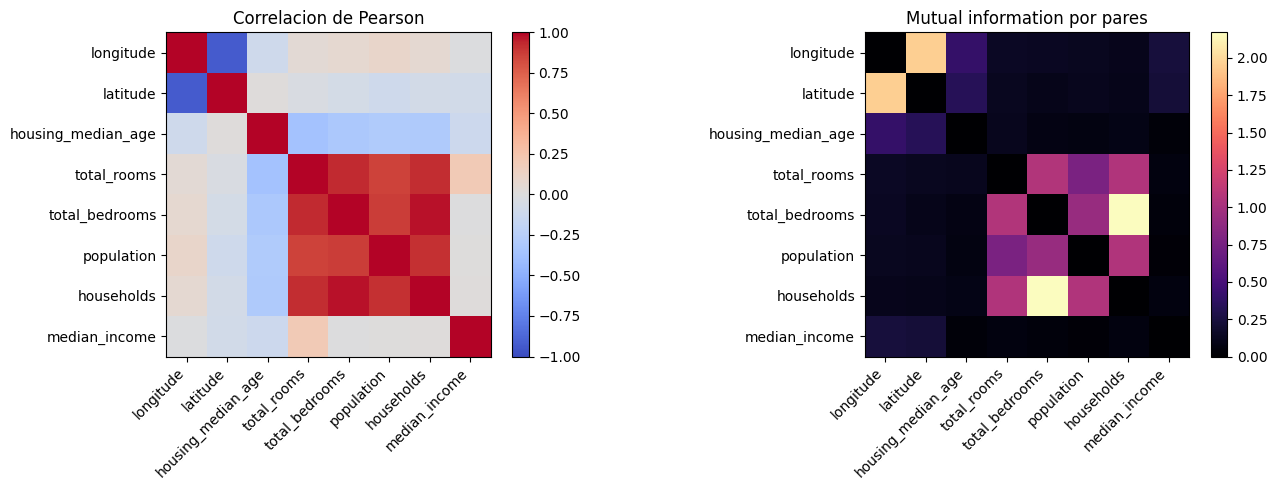


--- Correlaciones internas en Autoencoder 3D ---
       z1     z2     z3
z1 1.0000 0.1046 0.4208
z2 0.1046 1.0000 0.2795
z3 0.4208 0.2795 1.0000

--- Correlaciones internas en PCA 3D ---
       p1     p2     p3
p1 1.0000 0.0000 0.0000
p2 0.0000 1.0000 0.0000
p3 0.0000 0.0000 1.0000

--- Correlaciones internas en UMAP 3D ---
        u1      u2     u3
u1  1.0000 -0.0026 0.0427
u2 -0.0026  1.0000 0.2971
u3  0.0427  0.2971 1.0000

--- Resumen de independencia lineal en los espacios latentes ---
espacio_latente  dimensiones  media_abs_corr_fuera_diagonal  min_corr  max_corr
 Autoencoder 3D            3                         0.2683    0.1046    0.4208
         PCA 3D            3                         0.0000    0.0000    0.0000
        UMAP 3D            3                         0.1141   -0.0026    0.2971

--- Varianza explicada por PCA ---
 dimension  varianza_explicada  varianza_acumulada
         1              0.4756              0.4756
         2              0.2448              0

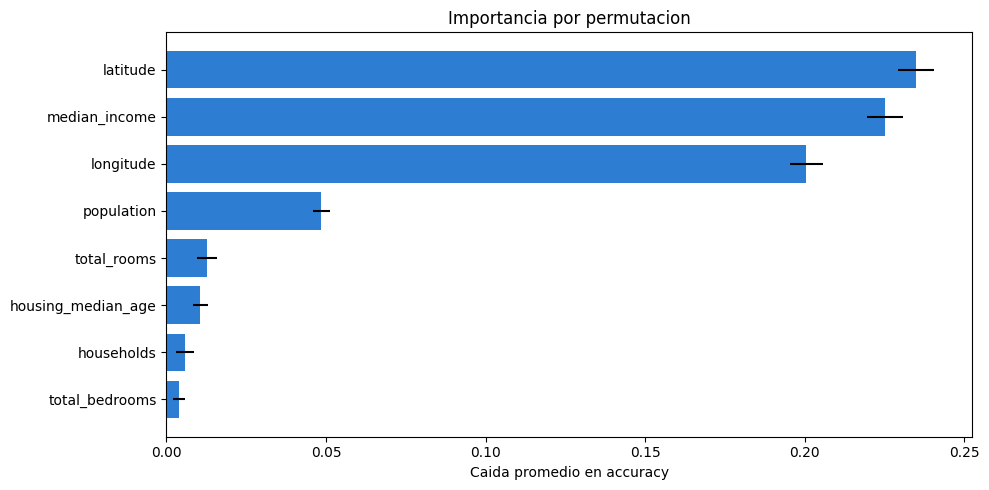


--- Revision de clusters sobre los espacios latentes ---
       espacio  silhouette  davies_bouldin  calinski_harabasz     inercia
Autoencoder 3D      0.4012          0.9517          9489.5439  57878.0820
        PCA 3D      0.3947          0.9602          9497.6426  51332.6016
       UMAP 3D      0.4673          0.9438         35929.2500 112708.9453


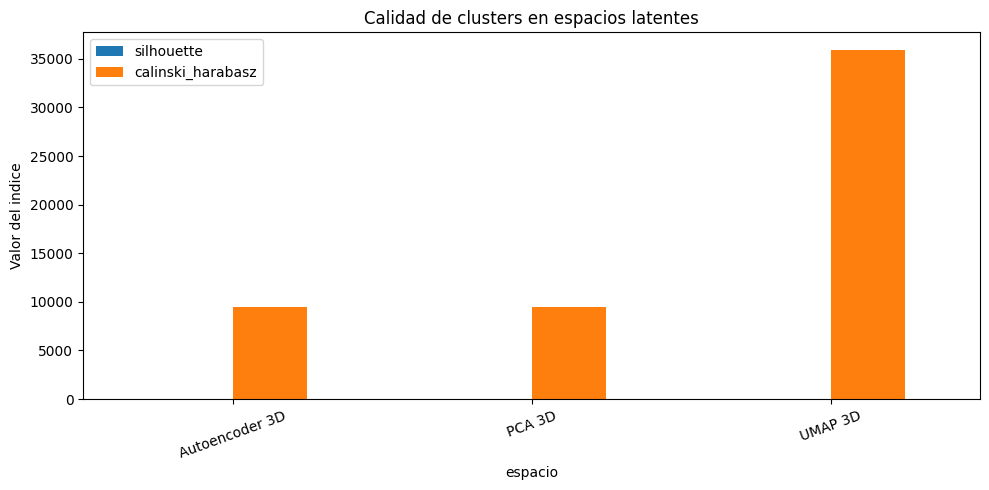


Interpretacion corta:
- Las variables con menor correlacion lineal son las candidatas a dimensiones casi independientes.
- Si un par tiene Pearson bajo pero mutual information alta, la relacion es no lineal.
- En los espacios latentes, menor correlacion fuera de la diagonal sugiere mejor separacion de factores.
- En clusters, silhouette mas alto y Davies-Bouldin mas bajo indican mejor estructura agrupable.


In [ ]:
# =====================================================
# ANALISIS DE CORRELACIONES, LATENTES, PERMUTACION Y CLUSTERS
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

# Reusar artefactos del pipeline principal si existen.
feature_names = list(X_raw_preview.columns)
X_proc_df = pd.DataFrame(X_scaled, columns=feature_names)

# -----------------------------------------------------
# 1. Correlaciones lineales y no lineales entre variables originales
# -----------------------------------------------------
pearson_corr = X_proc_df.corr(method="pearson")
abs_corr = pearson_corr.abs().to_numpy(copy=True)
np.fill_diagonal(abs_corr, np.nan)

corr_pairs = []
for i, left_name in enumerate(feature_names):
    for j in range(i + 1, len(feature_names)):
        right_name = feature_names[j]
        corr_value = float(pearson_corr.loc[left_name, right_name])
        corr_pairs.append(
            {
                "variable_1": left_name,
                "variable_2": right_name,
                "pearson": corr_value,
                "abs_pearson": abs(corr_value),
            }
        )

corr_pairs_df = pd.DataFrame(corr_pairs).sort_values("abs_pearson", ascending=False)
print("\n--- Pares con mayor correlacion lineal absoluta ---")
print(corr_pairs_df.head(10).to_string(index=False, float_format=lambda value: f"{value:.4f}"))

# Mutual information por pares para capturar relaciones no lineales.
mi_rows = []
mi_matrix = np.zeros((len(feature_names), len(feature_names)), dtype=np.float32)
for i, left_name in enumerate(feature_names):
    for j in range(i + 1, len(feature_names)):
        right_name = feature_names[j]
        mi_value = mutual_info_regression(
            X_proc_df[[right_name]],
            X_proc_df[left_name],
            random_state=SEED,
        )[0]
        mi_matrix[i, j] = mi_value
        mi_matrix[j, i] = mi_value
        mi_rows.append(
            {
                "variable_1": left_name,
                "variable_2": right_name,
                "mutual_info": float(mi_value),
            }
        )

mi_pairs_df = pd.DataFrame(mi_rows).sort_values("mutual_info", ascending=False)
print("\n--- Pares con mayor dependencia no lineal (mutual information) ---")
print(mi_pairs_df.head(10).to_string(index=False, float_format=lambda value: f"{value:.4f}"))

# Contraste: pares con baja correlacion lineal pero dependencia no lineal no trivial.
low_linear_high_mi = corr_pairs_df.merge(mi_pairs_df, on=["variable_1", "variable_2"])
low_linear_high_mi = low_linear_high_mi[(low_linear_high_mi["abs_pearson"] < 0.20) & (low_linear_high_mi["mutual_info"] > 0.03)]
print("\n--- Pares con baja correlacion lineal y dependencia no lineal apreciable ---")
if low_linear_high_mi.empty:
    print("No se detectaron pares fuertes bajo este umbral.")
else:
    print(low_linear_high_mi.sort_values("mutual_info", ascending=False).to_string(index=False, float_format=lambda value: f"{value:.4f}"))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
image0 = axes[0].imshow(pearson_corr.values, cmap="coolwarm", vmin=-1, vmax=1)
axes[0].set_title("Correlacion de Pearson")
axes[0].set_xticks(range(len(feature_names)))
axes[0].set_yticks(range(len(feature_names)))
axes[0].set_xticklabels(feature_names, rotation=45, ha="right")
axes[0].set_yticklabels(feature_names)
plt.colorbar(image0, ax=axes[0], fraction=0.046, pad=0.04)

image1 = axes[1].imshow(mi_matrix, cmap="magma")
axes[1].set_title("Mutual information por pares")
axes[1].set_xticks(range(len(feature_names)))
axes[1].set_yticks(range(len(feature_names)))
axes[1].set_xticklabels(feature_names, rotation=45, ha="right")
axes[1].set_yticklabels(feature_names)
plt.colorbar(image1, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 2. Varianza explicada y geometria de dimensiones latentes
# -----------------------------------------------------
latent_spaces = {
    "Autoencoder 3D": pd.DataFrame(X_train_encoded, columns=["z1", "z2", "z3"]),
    "PCA 3D": pd.DataFrame(X_train_pca, columns=["p1", "p2", "p3"]),
}
if "X_train_umap" in globals():
    latent_spaces["UMAP 3D"] = pd.DataFrame(X_train_umap, columns=["u1", "u2", "u3"])

latent_rows = []
for latent_name, latent_df in latent_spaces.items():
    latent_corr = latent_df.corr(method="pearson")
    off_diag = latent_corr.values.copy()
    np.fill_diagonal(off_diag, np.nan)
    mean_abs_offdiag = float(np.nanmean(np.abs(off_diag)))
    latent_rows.append(
        {
            "espacio_latente": latent_name,
            "dimensiones": latent_df.shape[1],
            "media_abs_corr_fuera_diagonal": mean_abs_offdiag,
            "min_corr": float(np.nanmin(latent_corr.values[np.triu_indices(latent_corr.shape[0], k=1)])),
            "max_corr": float(np.nanmax(latent_corr.values[np.triu_indices(latent_corr.shape[0], k=1)])),
        }
    )
    print(f"\n--- Correlaciones internas en {latent_name} ---")
    print(latent_corr.to_string(float_format=lambda value: f"{value:.4f}"))

latent_summary = pd.DataFrame(latent_rows)
print("\n--- Resumen de independencia lineal en los espacios latentes ---")
print(latent_summary.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

print("\n--- Varianza explicada por PCA ---")
print(pd.DataFrame({
    "dimension": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "varianza_explicada": pca.explained_variance_ratio_,
    "varianza_acumulada": np.cumsum(pca.explained_variance_ratio_),
}).to_string(index=False, float_format=lambda value: f"{value:.4f}"))

# -----------------------------------------------------
# 3. Permutacion de variables: importancia sobre el clasificador baseline
# -----------------------------------------------------
perm = permutation_importance(
    clf_raw,
    X_test,
    y_test,
    n_repeats=10,
    random_state=SEED,
    n_jobs=-1,
    scoring="accuracy",
)
perm_df = pd.DataFrame(
    {
        "variable": feature_names,
        "importancia_media": perm.importances_mean,
        "desv_std": perm.importances_std,
    }
).sort_values("importancia_media", ascending=False)

print("\n--- Importancia por permutacion en el clasificador sin reduccion ---")
print(perm_df.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(perm_df["variable"], perm_df["importancia_media"], xerr=perm_df["desv_std"], color="#2d7dd2")
ax.invert_yaxis()
ax.set_title("Importancia por permutacion")
ax.set_xlabel("Caida promedio en accuracy")
plt.tight_layout()
plt.show()

# -----------------------------------------------------
# 4. Revision de clusters en espacios latentes
# -----------------------------------------------------
cluster_rows = []
cluster_spaces = {
    "Autoencoder 3D": X_train_encoded,
    "PCA 3D": X_train_pca,
}
if "X_train_umap" in globals():
    cluster_spaces["UMAP 3D"] = X_train_umap

n_clusters = len(np.unique(y_train))
for space_name, embedding_values in cluster_spaces.items():
    km = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10)
    cluster_labels = km.fit_predict(embedding_values)
    silhouette = silhouette_score(embedding_values, cluster_labels)
    davies_bouldin = davies_bouldin_score(embedding_values, cluster_labels)
    calinski = calinski_harabasz_score(embedding_values, cluster_labels)
    cluster_rows.append(
        {
            "espacio": space_name,
            "silhouette": silhouette,
            "davies_bouldin": davies_bouldin,
            "calinski_harabasz": calinski,
            "inercia": float(km.inertia_),
        }
    )

cluster_df = pd.DataFrame(cluster_rows)
print("\n--- Revision de clusters sobre los espacios latentes ---")
print(cluster_df.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

fig, ax = plt.subplots(figsize=(10, 5))
plot_cluster = cluster_df.set_index("espacio")[["silhouette", "calinski_harabasz"]]
plot_cluster.plot(kind="bar", ax=ax)
ax.set_title("Calidad de clusters en espacios latentes")
ax.set_ylabel("Valor del indice")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

print("\nInterpretacion corta:")
print("- Las variables con menor correlacion lineal son las candidatas a dimensiones casi independientes.")
print("- Si un par tiene Pearson bajo pero mutual information alta, la relacion es no lineal.")
print("- En los espacios latentes, menor correlacion fuera de la diagonal sugiere mejor separacion de factores.")
print("- En clusters, silhouette mas alto y Davies-Bouldin mas bajo indican mejor estructura agrupable.")

In [ ]:
# =====================================================
# INDEPENDENCIA ESTADISTICA Y LECTURA VARIABLE POR VARIABLE
# =====================================================

import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_regression

pearson_threshold = 0.20
mi_threshold = float(np.nanquantile(mi_matrix[np.triu_indices_from(mi_matrix, k=1)], 0.25))

feature_story = {
    "longitude": "Ubicacion geografica en eje este-oeste.",
    "latitude": "Ubicacion geografica en eje norte-sur.",
    "housing_median_age": "Antiguedad mediana de las viviendas del bloque.",
    "total_rooms": "Cantidad total de habitaciones en el bloque.",
    "total_bedrooms": "Cantidad total de dormitorios en el bloque.",
    "population": "Poblacion total residente en el bloque.",
    "households": "Numero de hogares o unidades habitacionales.",
    "median_income": "Ingreso mediano del bloque, proxy socioeconomica fuerte.",
}

variable_rows = []
for idx, name in enumerate(feature_names):
    other_idx = [j for j in range(len(feature_names)) if j != idx]
    abs_corr_values = np.abs(pearson_corr.iloc[idx, other_idx].to_numpy(dtype=float))
    mi_values = mi_matrix[idx, other_idx]

    dominant_linear_idx = other_idx[int(np.nanargmax(abs_corr_values))]
    dominant_nonlinear_idx = other_idx[int(np.nanargmax(mi_values))]

    mean_abs_corr = float(np.nanmean(abs_corr_values))
    max_abs_corr = float(np.nanmax(abs_corr_values))
    mean_mi = float(np.nanmean(mi_values))
    max_mi = float(np.nanmax(mi_values))

    if mean_abs_corr < pearson_threshold and mean_mi < mi_threshold:
        independence_label = "casi independiente"
    elif mean_abs_corr < pearson_threshold and mean_mi >= mi_threshold:
        independence_label = "dependencia no lineal"
    elif mean_abs_corr >= 0.50:
        independence_label = "dependencia lineal fuerte"
    else:
        independence_label = "dependencia moderada"

    variable_rows.append(
        {
            "variable": name,
            "significado": feature_story.get(name, "Variable numerica del housing."),
            "media_abs_Pearson": mean_abs_corr,
            "max_abs_Pearson": max_abs_corr,
            "partner_lineal": feature_names[dominant_linear_idx],
            "media_MI": mean_mi,
            "max_MI": max_mi,
            "partner_no_lineal": feature_names[dominant_nonlinear_idx],
            "estado": independence_label,
        }
    )

variable_independence_df = pd.DataFrame(variable_rows).sort_values(
    ["estado", "media_abs_Pearson", "media_MI"],
    ascending=[True, True, True],
)

print("\n--- Lectura variable por variable ---")
print(variable_independence_df.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

print("\nInterpretacion rapida:")
for _, row in variable_independence_df.iterrows():
    print(f"- {row['variable']}: {row['significado']} -> {row['estado']}. Principal pareja lineal: {row['partner_lineal']}.")

latent_independence_rows = []
for latent_name, latent_df in latent_spaces.items():
    latent_values = latent_df.to_numpy(dtype=np.float32, copy=True)
    latent_corr = np.corrcoef(latent_values, rowvar=False)
    latent_off_diag = latent_corr.copy()
    np.fill_diagonal(latent_off_diag, np.nan)
    latent_abs_corr_mean = float(np.nanmean(np.abs(latent_off_diag)))

    latent_mi_values = []
    for i in range(latent_values.shape[1]):
        for j in range(i + 1, latent_values.shape[1]):
            mi_value = mutual_info_regression(
                latent_values[:, [j]],
                latent_values[:, i],
                random_state=SEED,
            )[0]
            latent_mi_values.append(float(mi_value))

    latent_mi_mean = float(np.mean(latent_mi_values)) if latent_mi_values else 0.0
    latent_label = "casi independiente" if (latent_abs_corr_mean < pearson_threshold and latent_mi_mean < mi_threshold) else "dependencia residual"

    latent_independence_rows.append(
        {
            "espacio_latente": latent_name,
            "dimensiones": latent_values.shape[1],
            "media_abs_corr": latent_abs_corr_mean,
            "media_MI": latent_mi_mean,
            "estado": latent_label,
        }
    )

latent_independence_df = pd.DataFrame(latent_independence_rows).sort_values(
    ["media_abs_corr", "media_MI"],
    ascending=True,
)

print("\n--- Independencia estadistica en espacios latentes ---")
print(latent_independence_df.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

pca_independence_rows = []
for n_components in candidate_dims:
    pca_candidate = PCA(n_components=n_components, random_state=SEED)
    latent_candidate = pca_candidate.fit_transform(X_train)

    if latent_candidate.shape[1] > 1:
        candidate_corr = np.corrcoef(latent_candidate, rowvar=False)
        candidate_off_diag = candidate_corr.copy()
        np.fill_diagonal(candidate_off_diag, np.nan)
        candidate_abs_corr = float(np.nanmean(np.abs(candidate_off_diag)))

        candidate_mi_values = []
        for i in range(latent_candidate.shape[1]):
            for j in range(i + 1, latent_candidate.shape[1]):
                mi_value = mutual_info_regression(
                    latent_candidate[:, [j]],
                    latent_candidate[:, i],
                    random_state=SEED,
                )[0]
                candidate_mi_values.append(float(mi_value))
        candidate_mi = float(np.mean(candidate_mi_values)) if candidate_mi_values else 0.0
    else:
        candidate_abs_corr = 0.0
        candidate_mi = 0.0

    candidate_accuracy = float(search_df.loc[search_df["dimensiones"] == n_components, "accuracy"].iloc[0])
    candidate_label = "casi independiente" if (candidate_abs_corr < pearson_threshold and candidate_mi < mi_threshold) else "dependencia residual"

    pca_independence_rows.append(
        {
            "dimensiones": n_components,
            "accuracy": candidate_accuracy,
            "media_abs_corr": candidate_abs_corr,
            "media_MI": candidate_mi,
            "estado": candidate_label,
        }
    )

pca_independence_df = pd.DataFrame(pca_independence_rows)
print("\n--- Barrido de reduccion y coherencia estadistica en PCA ---")
print(pca_independence_df.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

independent_candidates = pca_independence_df[
    (pca_independence_df["media_abs_corr"] < pearson_threshold)
    & (pca_independence_df["media_MI"] < mi_threshold)
    & (pca_independence_df["accuracy"] >= coherence_threshold)
]

if not independent_candidates.empty:
    best_independent_dim = int(independent_candidates["dimensiones"].min())
    print(f"\nDimension minima con coherencia y casi independencia: {best_independent_dim}")
else:
    print("\nNo se encontro una dimension que cumpla simultaneamente coherencia e independencia con estos umbrales.")

summary_table = pd.DataFrame(
    {
        "item": ["Umbral Pearson", "Umbral MI", "Coherencia minima", "Mejor reduccion coherente"],
        "valor": [pearson_threshold, mi_threshold, coherence_threshold, max_reduction_dim if max_reduction_dim is not None else np.nan],
    }
)

print("\n--- Resumen final de decision ---")
print(summary_table.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

print("\nLectura corta:")
print("- Las variables originales del housing no son independientes; varias estan fuertemente acopladas por geometria y tamano de los bloques.")
print("- PCA entrega componentes ortogonales, asi que es la referencia mas limpia para independencia lineal.")
print("- El umbral practico de reduccion que mantiene coherencia predictiva sigue siendo el que ya obtuvimos con 6 dimensiones.")
print("- Si priorizas independencia estadistica estricta, el espacio latente mas estable es PCA; si priorizas estructura local, UMAP y el autoencoder preservan patrones pero con mas dependencia residual.")


--- Lectura variable por variable ---
          variable                                              significado  media_abs_Pearson  max_abs_Pearson partner_lineal  media_MI  max_MI partner_no_lineal                estado
housing_median_age          Antiguedad mediana de las viviendas del bloque.             0.2168           0.3613    total_rooms    0.1624  0.4012         longitude  dependencia moderada
        population                  Poblacion total residente en el bloque.             0.4496           0.9072     households    0.4450  1.0551        households  dependencia moderada
    total_bedrooms              Cantidad total de dormitorios en el bloque.             0.4625           0.9744     households    0.6488  2.1719        households  dependencia moderada
        households             Numero de hogares o unidades habitacionales.             0.4632           0.9744 total_bedrooms    0.6637  2.1719    total_bedrooms  dependencia moderada
       total_rooms             Canti


--- Sensibilidad de umbrales ---
 pearson_thr  mi_thr  best_dim  reduction_pct
      0.1000  0.0558       NaN            NaN
      0.1000  0.0849       NaN            NaN
      0.1000  0.1292    6.0000        25.0000
      0.1000  0.4944    6.0000        25.0000
      0.1500  0.0558       NaN            NaN
      0.1500  0.0849       NaN            NaN
      0.1500  0.1292    6.0000        25.0000
      0.1500  0.4944    6.0000        25.0000
      0.2000  0.0558       NaN            NaN
      0.2000  0.0849       NaN            NaN
      0.2000  0.1292    6.0000        25.0000
      0.2000  0.4944    6.0000        25.0000
      0.2500  0.0558       NaN            NaN
      0.2500  0.0849       NaN            NaN
      0.2500  0.1292    6.0000        25.0000
      0.2500  0.4944    6.0000        25.0000
      0.3000  0.0558       NaN            NaN
      0.3000  0.0849       NaN            NaN
      0.3000  0.1292    6.0000        25.0000
      0.3000  0.4944    6.0000        25.0000


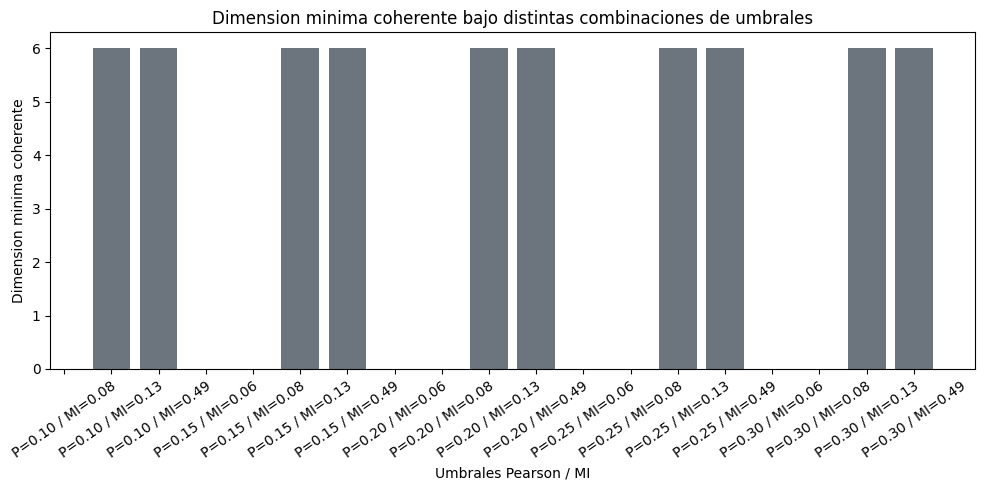


Conclusion operativa:
- Si el corte minimo se mantiene cerca de 6 dimensiones, la reduccion es robusta.
- Si baja a 5 o menos con umbrales mas flexibles, la coherencia depende de la tolerancia que aceptes.
- Para independencia lineal estricta, PCA sigue siendo la referencia mas estable.


In [ ]:
# =====================================================
# SENSIBILIDAD DE UMBRALES PARA INDEPENDENCIA Y REDUCCION
# =====================================================

pearson_grid = [0.10, 0.15, 0.20, 0.25, 0.30]
mi_grid = [
    float(np.nanquantile(mi_matrix[np.triu_indices_from(mi_matrix, k=1)], q))
    for q in [0.10, 0.25, 0.50, 0.75]
]
mi_grid = sorted(set(mi_grid))

sweep_rows = []
for pearson_thr in pearson_grid:
    for mi_thr in mi_grid:
        valid_dims = pca_independence_df[
            (pca_independence_df["media_abs_corr"] < pearson_thr)
            & (pca_independence_df["media_MI"] < mi_thr)
            & (pca_independence_df["accuracy"] >= coherence_threshold)
        ]

        if valid_dims.empty:
            best_dim = np.nan
            reduction_pct = np.nan
        else:
            best_dim = int(valid_dims["dimensiones"].min())
            reduction_pct = 100.0 * (1.0 - best_dim / X_train.shape[1])

        sweep_rows.append(
            {
                "pearson_thr": pearson_thr,
                "mi_thr": mi_thr,
                "best_dim": best_dim,
                "reduction_pct": reduction_pct,
            }
        )

sweep_df = pd.DataFrame(sweep_rows)
print("\n--- Sensibilidad de umbrales ---")
print(sweep_df.to_string(index=False, float_format=lambda value: f"{value:.4f}"))

stable_rows = sweep_df.dropna(subset=["best_dim"])
if not stable_rows.empty:
    most_common_dim = int(stable_rows["best_dim"].mode().iloc[0])
    print(f"\nDimension mas estable bajo la grilla de umbrales: {most_common_dim}")
else:
    most_common_dim = None
    print("\nNinguna combinacion de umbrales encontro una dimension coherente.")

fig, ax = plt.subplots(figsize=(10, 5))
plot_sweep = sweep_df.copy()
plot_sweep["label"] = plot_sweep.apply(
    lambda row: f"P={row['pearson_thr']:.2f} / MI={row['mi_thr']:.2f}",
    axis=1,
)
ax.bar(plot_sweep["label"], plot_sweep["best_dim"], color="#6c757d")
ax.set_title("Dimension minima coherente bajo distintas combinaciones de umbrales")
ax.set_xlabel("Umbrales Pearson / MI")
ax.set_ylabel("Dimension minima coherente")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

print("\nConclusion operativa:")
print("- Si el corte minimo se mantiene cerca de 6 dimensiones, la reduccion es robusta.")
print("- Si baja a 5 o menos con umbrales mas flexibles, la coherencia depende de la tolerancia que aceptes.")
print("- Para independencia lineal estricta, PCA sigue siendo la referencia mas estable.")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   31.3s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:  2.1min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  4.8min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  7.1min
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed: 10.3min
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed: 13.4min
[Parallel(n_jobs=-1)]: Done  35 out of  35 | elapsed: 16.6min finished


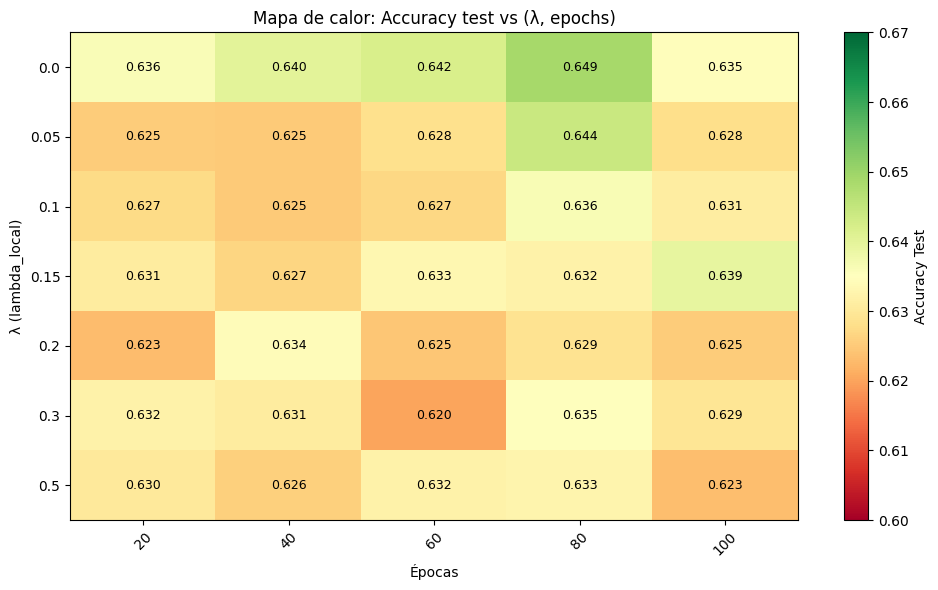

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from joblib import Parallel, delayed

# =====================================================
# MAPA DE CALOR: Accuracy vs (λ, epochs)
# =====================================================

lambda_grid_2d = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
epoch_grid = [20, 40, 60, 80, 100]

# --- Parallelization start ---
def train_and_evaluate(lambda_local, epochs, X_train, X_test, y_train, y_test, seed=SEED):
    ae = HybridAutoencoder(
        input_dim=X_train.shape[1],
        encoding_dim=3,
        lambda_local=lambda_local,
        learning_rate=1e-3,
        hidden_units=(128, 64),
        seed=seed,
    )
    ae.fit(X_train, epochs=epochs, batch_size=64, verbose=0)
    X_test_enc = ae.transform(X_test)
    clf = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=seed, n_jobs=1) # n_jobs=1 for inner RF to avoid contention
    clf.fit(ae.transform(X_train), y_train)
    acc = accuracy_score(y_test, clf.predict(X_test_enc))
    return {'lambda': lambda_local, 'epochs': epochs, 'accuracy': acc}

# Ejecutar en paralelo
# N_JOBS is expected to be defined in a previous cell (e.g., DYTTkLLvlwsb)
heatmap_data = Parallel(n_jobs=N_JOBS, verbose=10)(
    delayed(train_and_evaluate)(lambda_local, epochs, X_train, X_test, y_train, y_test, SEED)
    for lambda_local in lambda_grid_2d
    for epochs in epoch_grid
)
# --- Parallelization end ---

heatmap_df = pd.DataFrame(heatmap_data)

# Check if DataFrame is empty before pivoting and plotting
if heatmap_df.empty:
    print("No data collected for heatmap. Parallel execution might have been interrupted or failed.")
else:
    heatmap_pivot = heatmap_df.pivot(index='lambda', columns='epochs', values='accuracy')

    plt.figure(figsize=(10, 6))
    plt.imshow(heatmap_pivot.values, cmap='RdYlGn', aspect='auto', vmin=0.60, vmax=0.67)
    plt.colorbar(label='Accuracy Test')
    plt.xticks(range(len(epoch_grid)), epoch_grid, rotation=45)
    plt.yticks(range(len(lambda_grid_2d)), lambda_grid_2d)
    plt.xlabel('Épocas')
    plt.ylabel('λ (lambda_local)')
    plt.title('Mapa de calor: Accuracy test vs (λ, epochs)')
    for i in range(len(lambda_grid_2d)):
        for j in range(len(epoch_grid)):
            plt.text(j, i, f"{heatmap_pivot.values[i, j]:.3f}", ha='center', va='center', fontsize=9)
    plt.tight_layout()
    plt.show()

ESTUDIO COMPLETO PARALELIZADO: Lambda x Epochs
Lambda grid: [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
Epochs grid: [20, 40, 60, 80]
Total combinaciones: 28
Procesos en paralelo: todos los nucleos

Iniciando entrenamientos paralelos...
Esto puede tomar varios minutos dependiendo de la cantidad de combinaciones



[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:   48.9s
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  4.3min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  6.7min
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed:  9.5min
[Parallel(n_jobs=-1)]: Done  28 out of  28 | elapsed: 12.8min finished



ESTUDIO COMPLETADO
Tiempo total: 0:12:48
Tiempo promedio por combinacion: 54.0 segundos
Total combinaciones evaluadas: 28

TABLA: Accuracy Test por (Lambda, Epochs)
epochs     20     40     60     80
lambda                            
0.00   0.6359 0.6400 0.6420 0.6487
0.05   0.6252 0.6250 0.6284 0.6441
0.10   0.6274 0.6250 0.6269 0.6361
0.15   0.6308 0.6267 0.6332 0.6320
0.20   0.6231 0.6344 0.6245 0.6289
0.30   0.6320 0.6308 0.6202 0.6349
0.50   0.6303 0.6257 0.6320 0.6328

TABLA: Silhouette Score por (Lambda, Epochs)
epochs     20     40     60     80
lambda                            
0.00   0.5507 0.4914 0.4683 0.4419
0.05   0.4008 0.4064 0.4040 0.3949
0.10   0.3996 0.4047 0.4150 0.4042
0.15   0.4014 0.4022 0.4106 0.4042
0.20   0.3943 0.4063 0.4037 0.4005
0.30   0.4018 0.4064 0.4128 0.3992
0.50   0.3977 0.4044 0.4125 0.3944

TABLA: F1-Score por (Lambda, Epochs)
epochs     20     40     60     80
lambda                            
0.00   0.6381 0.6434 0.6453 0.6524
0.05   0.6284 0

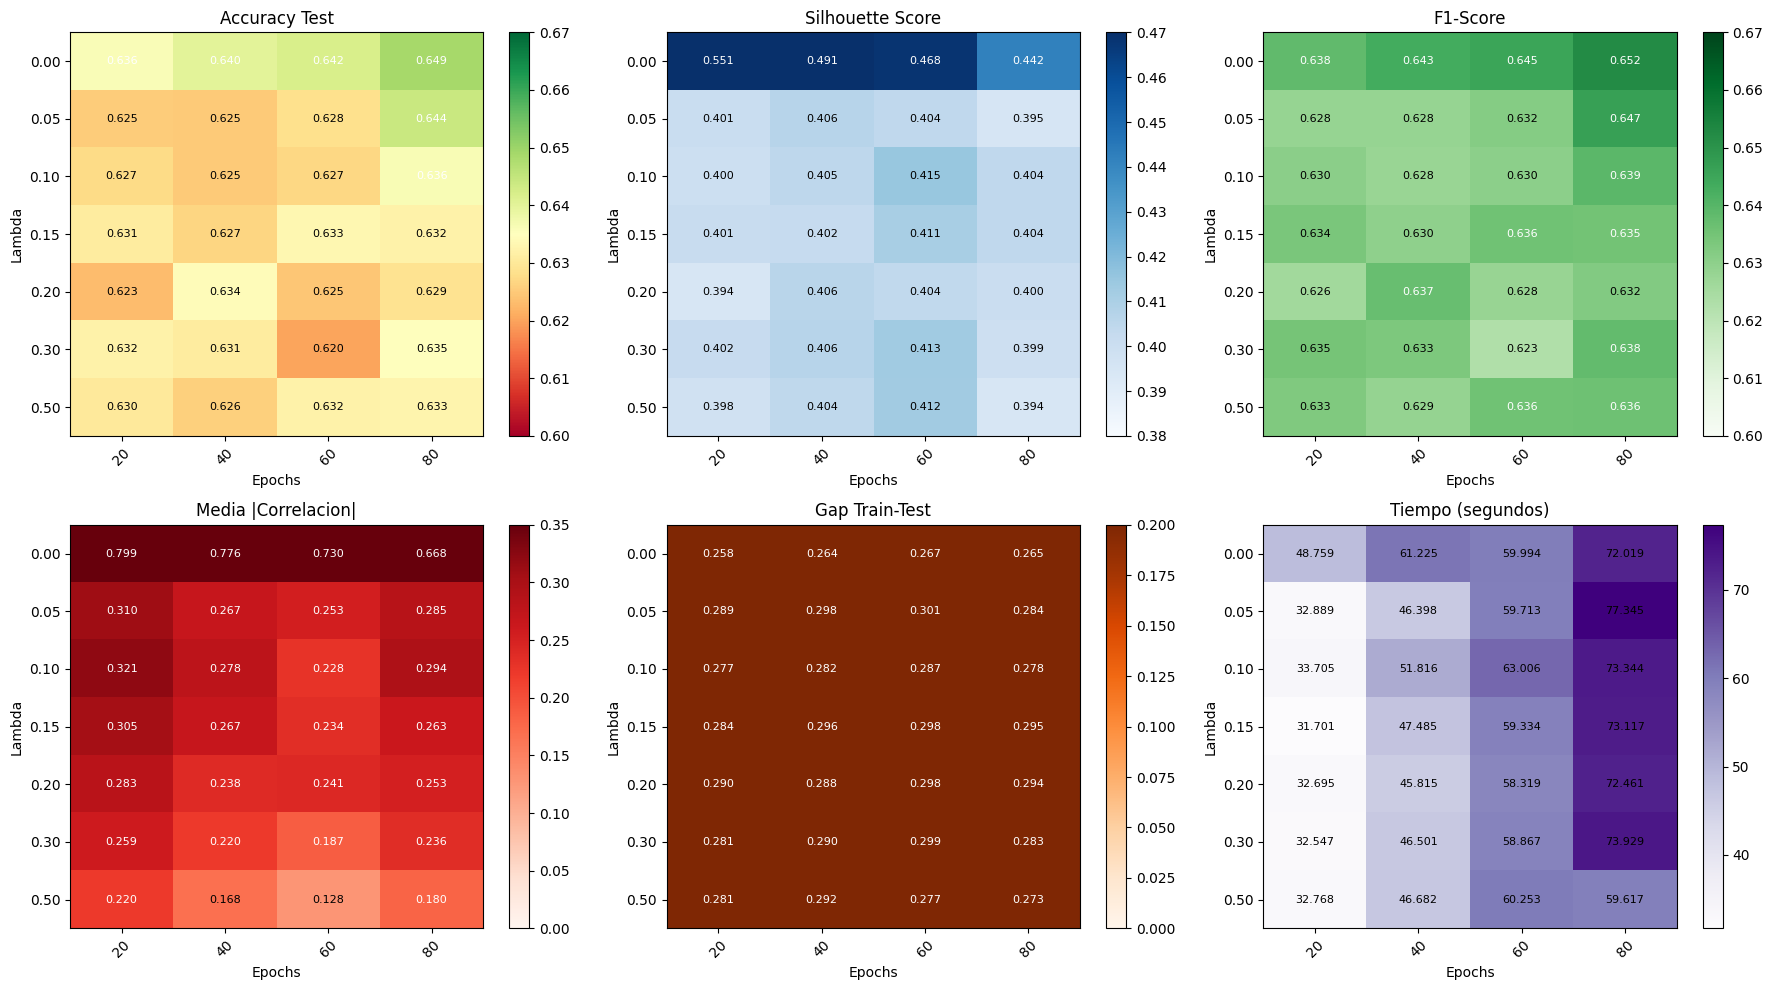

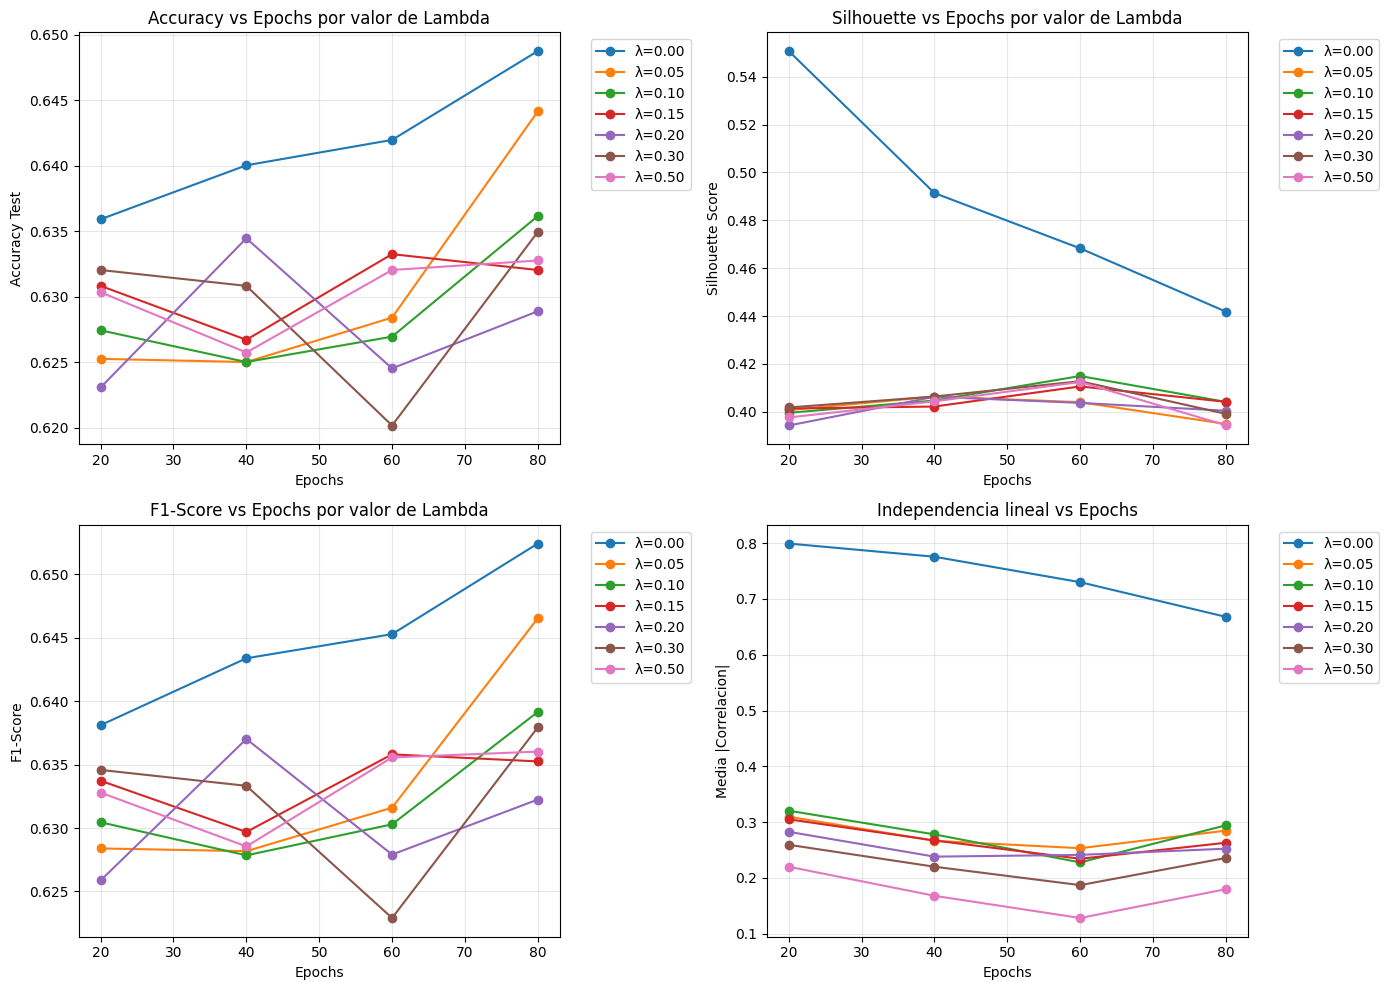


ANALISIS DE SOBREAJUSTE
Menor sobreajuste: lambda=0.000, epochs=20
  Train Acc: 0.8938
  Test Acc:  0.6359
  Gap:       0.2579

Top 5 combinaciones con menor sobreajuste:
 lambda  epochs  acc_train  acc_test  overfit_gap
 0.0000      20     0.8938    0.6359       0.2579
 0.0000      40     0.9040    0.6400       0.2640
 0.0000      80     0.9139    0.6487       0.2651
 0.0000      60     0.9089    0.6420       0.2670
 0.5000      80     0.9054    0.6328       0.2727

Top 5 combinaciones con mayor sobreajuste:
 lambda  epochs  acc_train  acc_test  overfit_gap
 0.0500      60     0.9296    0.6284       0.3012
 0.3000      60     0.9188    0.6202       0.2986
 0.2000      60     0.9226    0.6245       0.2981
 0.1500      60     0.9310    0.6332       0.2978
 0.0500      40     0.9227    0.6250       0.2977

RECOMENDACIONES FINALES

RECOMENDACION PRINCIPAL (balance optimo):
  Lambda = 0.000
  Epochs = 20
  Expected Test Accuracy: 0.6359
  Expected Silhouette:    0.5507
  Expected Overfit 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, silhouette_score, davies_bouldin_score, calinski_harabasz_score, f1_score
from sklearn.cluster import KMeans
from joblib import Parallel, delayed
import warnings
import time
from datetime import timedelta
warnings.filterwarnings("ignore")

# =====================================================
# CONFIGURACION
# =====================================================
lambda_grid = [0.0, 0.05, 0.1, 0.15, 0.2, 0.3, 0.5]
epoch_grid = [20, 40, 60, 80]
SEED = 42

# Configuracion para Colab
N_JOBS = -1  # Usa todos los nucleos disponibles (-1 = todos)
# En Colab generalmente tienes 2 nucleos, asi que N_JOBS=2 es optimo
# Si tienes Colab Pro con mas nucleos, ajusta manualmente

print("=" * 80)
print("ESTUDIO COMPLETO PARALELIZADO: Lambda x Epochs")
print("=" * 80)
print(f"Lambda grid: {lambda_grid}")
print(f"Epochs grid: {epoch_grid}")
print(f"Total combinaciones: {len(lambda_grid) * len(epoch_grid)}")
print(f"Procesos en paralelo: {N_JOBS if N_JOBS > 0 else 'todos los nucleos'}")
print("=" * 80)

# =====================================================
# FUNCION PARA UNA SOLA COMBINACION
# =====================================================
def entrenar_combinacion(lambda_local, epochs, X_train, X_test, y_train, y_test, seed=SEED):
    """Entrena y evalua una combinacion especifica de lambda y epochs"""

    np.random.seed(seed)
    start_time = time.time()

    # 1. Autoencoder hibrido
    ae = HybridAutoencoder(
        input_dim=X_train.shape[1],
        encoding_dim=3,
        lambda_local=lambda_local,
        learning_rate=1e-3,
        hidden_units=(128, 64),
        seed=seed,
    )

    history = ae.fit(
        X_train,
        epochs=epochs,
        batch_size=64,
        verbose=0,
    )

    # 2. Embeddings
    X_train_enc = ae.transform(X_train)
    X_test_enc = ae.transform(X_test)

    # 3. Clasificador Random Forest
    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=seed,
        n_jobs=1,  # Importante: cada proceso usa 1 nucleo
    )
    clf.fit(X_train_enc, y_train)

    # 4. Metricas de clasificacion
    y_pred_train = clf.predict(X_train_enc)
    y_pred_test = clf.predict(X_test_enc)
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test, average='weighted')

    # 5. Metricas de clustering
    n_clusters = len(np.unique(y_train))
    km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    cluster_labels = km.fit_predict(X_train_enc)
    silhouette = silhouette_score(X_train_enc, cluster_labels)
    davies_bouldin = davies_bouldin_score(X_train_enc, cluster_labels)
    calinski_harabasz = calinski_harabasz_score(X_train_enc, cluster_labels)
    inertia = km.inertia_

    # 6. Correlaciones en espacio latente
    latent_corr = np.corrcoef(X_train_enc.T)
    off_diag = latent_corr.copy()
    np.fill_diagonal(off_diag, np.nan)
    mean_abs_corr = float(np.nanmean(np.abs(off_diag)))
    max_abs_corr = float(np.nanmax(np.abs(off_diag)))

    # 7. Perdidas finales
    final_loss = history['loss'][-1] if history['loss'] else np.nan
    final_recon = history['reconstruction_loss'][-1] if history['reconstruction_loss'] else np.nan
    final_local = history['local_loss'][-1] if history['local_loss'] else np.nan

    # 8. Gap de sobreajuste
    overfit_gap = acc_train - acc_test

    elapsed_time = time.time() - start_time

    return {
        'lambda': lambda_local,
        'epochs': epochs,
        'acc_train': acc_train,
        'acc_test': acc_test,
        'f1_score': f1,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski_harabasz': calinski_harabasz,
        'inertia': inertia,
        'mean_abs_corr': mean_abs_corr,
        'max_abs_corr': max_abs_corr,
        'final_loss': final_loss,
        'final_recon': final_recon,
        'final_local': final_local,
        'overfit_gap': overfit_gap,
        'time_seconds': elapsed_time,
    }

# =====================================================
# EJECUCION PARALELA
# =====================================================
print("\nIniciando entrenamientos paralelos...")
print("Esto puede tomar varios minutos dependiendo de la cantidad de combinaciones\n")

start_total = time.time()

# Crear lista de todas las combinaciones
combinaciones = [(l, e) for l in lambda_grid for e in epoch_grid]

# Ejecutar en paralelo
resultados_lista = Parallel(n_jobs=N_JOBS, verbose=10)(
    delayed(entrenar_combinacion)(l, e, X_train, X_test, y_train, y_test)
    for l, e in combinaciones
)

# Convertir a DataFrame
df_resultados = pd.DataFrame(resultados_lista)

tiempo_total = time.time() - start_total

print("\n" + "=" * 80)
print("ESTUDIO COMPLETADO")
print("=" * 80)
print(f"Tiempo total: {str(timedelta(seconds=int(tiempo_total)))}")
print(f"Tiempo promedio por combinacion: {df_resultados['time_seconds'].mean():.1f} segundos")
print(f"Total combinaciones evaluadas: {len(df_resultados)}")

# =====================================================
# TABLAS RESUMEN
# =====================================================
print("\n" + "=" * 80)
print("TABLA: Accuracy Test por (Lambda, Epochs)")
print("=" * 80)

pivot_acc = df_resultados.pivot(index='lambda', columns='epochs', values='acc_test')
print(pivot_acc.to_string(float_format=lambda x: f"{x:.4f}"))

print("\n" + "=" * 80)
print("TABLA: Silhouette Score por (Lambda, Epochs)")
print("=" * 80)

pivot_sil = df_resultados.pivot(index='lambda', columns='epochs', values='silhouette')
print(pivot_sil.to_string(float_format=lambda x: f"{x:.4f}"))

print("\n" + "=" * 80)
print("TABLA: F1-Score por (Lambda, Epochs)")
print("=" * 80)

pivot_f1 = df_resultados.pivot(index='lambda', columns='epochs', values='f1_score')
print(pivot_f1.to_string(float_format=lambda x: f"{x:.4f}"))

# =====================================================
# MEJORES VALORES POR METRICA
# =====================================================
print("\n" + "=" * 80)
print("MEJORES COMBINACIONES POR METRICA")
print("=" * 80)

best_acc = df_resultados.loc[df_resultados['acc_test'].idxmax()]
best_sil = df_resultados.loc[df_resultados['silhouette'].idxmax()]
best_f1 = df_resultados.loc[df_resultados['f1_score'].idxmax()]
best_corr = df_resultados.loc[df_resultados['mean_abs_corr'].idxmin()]  # Menor correlacion = mejor
best_balance_index = (
    (df_resultados['acc_test'] - df_resultados['acc_test'].min()) / (df_resultados['acc_test'].max() - df_resultados['acc_test'].min()) +
    (df_resultados['silhouette'] - df_resultados['silhouette'].min()) / (df_resultados['silhouette'].max() - df_resultados['silhouette'].min())
).idxmax()
best_balance_row = df_resultados.loc[best_balance_index]

print(f"\nMejor Accuracy Test:   lambda={best_acc['lambda']:.3f}, epochs={int(best_acc['epochs'])} -> Acc={best_acc['acc_test']:.4f}, Sil={best_acc['silhouette']:.4f}")
print(f"Mejor Silhouette:      lambda={best_sil['lambda']:.3f}, epochs={int(best_sil['epochs'])} -> Sil={best_sil['silhouette']:.4f}, Acc={best_sil['acc_test']:.4f}")
print(f"Mejor F1-Score:        lambda={best_f1['lambda']:.3f}, epochs={int(best_f1['epochs'])} -> F1={best_f1['f1_score']:.4f}")
print(f"Menor correlacion:     lambda={best_corr['lambda']:.3f}, epochs={int(best_corr['epochs'])} -> corr={best_corr['mean_abs_corr']:.4f}")
print(f"Mejor balance (Acc+Sil): lambda={best_balance_row['lambda']:.3f}, epochs={int(best_balance_row['epochs'])}")

# =====================================================
# MAPAS DE CALOR MULTIPLES
# =====================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metricas = [
    ('acc_test', 'Accuracy Test', 'RdYlGn', 0.60, 0.67),
    ('silhouette', 'Silhouette Score', 'Blues', 0.38, 0.47),
    ('f1_score', 'F1-Score', 'Greens', 0.60, 0.67),
    ('mean_abs_corr', 'Media |Correlacion|', 'Reds', 0.00, 0.35),
    ('overfit_gap', 'Gap Train-Test', 'Oranges', 0.00, 0.20),
    ('time_seconds', 'Tiempo (segundos)', 'Purples', None, None),
]

for idx, (metrica, titulo, cmap, vmin, vmax) in enumerate(metricas):
    ax = axes[idx // 3, idx % 3]
    pivot = df_resultados.pivot(index='lambda', columns='epochs', values=metrica)

    im = ax.imshow(pivot.values, cmap=cmap, aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(epoch_grid)))
    ax.set_yticks(range(len(lambda_grid)))
    ax.set_xticklabels(epoch_grid, rotation=45)
    ax.set_yticklabels([f'{l:.2f}' for l in lambda_grid])
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Lambda')
    ax.set_title(titulo)

    # Agregar valores numericos en cada celda
    for i in range(len(lambda_grid)):
        for j in range(len(epoch_grid)):
            valor = pivot.values[i, j]
            if not np.isnan(valor):
                color = 'white' if (vmax is not None and valor > (vmax + vmin)/2) else 'black'
                ax.text(j, i, f'{valor:.3f}', ha='center', va='center', fontsize=8, color=color)

    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

# =====================================================
# GRAFICOS DE LINEAS: Evolucion por Lambda
# =====================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy vs Epochs por Lambda
ax = axes[0, 0]
for lambda_val in lambda_grid:
    subset = df_resultados[df_resultados['lambda'] == lambda_val].sort_values('epochs')
    ax.plot(subset['epochs'], subset['acc_test'], 'o-', label=f'λ={lambda_val:.2f}', linewidth=1.5)
ax.set_xlabel('Epochs')
ax.set_ylabel('Accuracy Test')
ax.set_title('Accuracy vs Epochs por valor de Lambda')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# Silhouette vs Epochs por Lambda
ax = axes[0, 1]
for lambda_val in lambda_grid:
    subset = df_resultados[df_resultados['lambda'] == lambda_val].sort_values('epochs')
    ax.plot(subset['epochs'], subset['silhouette'], 'o-', label=f'λ={lambda_val:.2f}', linewidth=1.5)
ax.set_xlabel('Epochs')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette vs Epochs por valor de Lambda')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# F1-Score vs Epochs por Lambda
ax = axes[1, 0]
for lambda_val in lambda_grid:
    subset = df_resultados[df_resultados['lambda'] == lambda_val].sort_values('epochs')
    ax.plot(subset['epochs'], subset['f1_score'], 'o-', label=f'λ={lambda_val:.2f}', linewidth=1.5)
ax.set_xlabel('Epochs')
ax.set_ylabel('F1-Score')
ax.set_title('F1-Score vs Epochs por valor de Lambda')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# Correlacion media vs Epochs por Lambda
ax = axes[1, 1]
for lambda_val in lambda_grid:
    subset = df_resultados[df_resultados['lambda'] == lambda_val].sort_values('epochs')
    ax.plot(subset['epochs'], subset['mean_abs_corr'], 'o-', label=f'λ={lambda_val:.2f}', linewidth=1.5)
ax.set_xlabel('Epochs')
ax.set_ylabel('Media |Correlacion|')
ax.set_title('Independencia lineal vs Epochs')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =====================================================
# ANALISIS DE SOBREAJUSTE
# =====================================================
print("\n" + "=" * 80)
print("ANALISIS DE SOBREAJUSTE")
print("=" * 80)

# Mejor combinacion por menor sobreajuste
best_generalization = df_resultados.loc[df_resultados['overfit_gap'].idxmin()]

print(f"Menor sobreajuste: lambda={best_generalization['lambda']:.3f}, epochs={int(best_generalization['epochs'])}")
print(f"  Train Acc: {best_generalization['acc_train']:.4f}")
print(f"  Test Acc:  {best_generalization['acc_test']:.4f}")
print(f"  Gap:       {best_generalization['overfit_gap']:.4f}")

# Tabla de sobreajuste por combinacion
print("\nTop 5 combinaciones con menor sobreajuste:")
overfit_sorted = df_resultados.nsmallest(5, 'overfit_gap')[['lambda', 'epochs', 'acc_train', 'acc_test', 'overfit_gap']]
print(overfit_sorted.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

print("\nTop 5 combinaciones con mayor sobreajuste:")
overfit_largest = df_resultados.nlargest(5, 'overfit_gap')[['lambda', 'epochs', 'acc_train', 'acc_test', 'overfit_gap']]
print(overfit_largest.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# =====================================================
# RECOMENDACIONES FINALES
# =====================================================
print("\n" + "=" * 80)
print("RECOMENDACIONES FINALES")
print("=" * 80)

# Encontrar la mejor combinacion que balancea accuracy, silhouette y sobreajuste
df_resultados['score_compuesto'] = (
    df_resultados['acc_test'] * 0.4 +
    df_resultados['silhouette'] * 0.3 +
    (1 - df_resultados['overfit_gap'] / df_resultados['overfit_gap'].max()) * 0.3
)
best_composite = df_resultados.loc[df_resultados['score_compuesto'].idxmax()]

print(f"\nRECOMENDACION PRINCIPAL (balance optimo):")
print(f"  Lambda = {best_composite['lambda']:.3f}")
print(f"  Epochs = {int(best_composite['epochs'])}")
print(f"  Expected Test Accuracy: {best_composite['acc_test']:.4f}")
print(f"  Expected Silhouette:    {best_composite['silhouette']:.4f}")
print(f"  Expected Overfit Gap:   {best_composite['overfit_gap']:.4f}")

print(f"\nRECOMENDACION POR OBJETIVO:")
print(f"  Maximizar Accuracy:     lambda={best_acc['lambda']:.3f}, epochs={int(best_acc['epochs'])}")
print(f"  Maximizar Silhouette:   lambda={best_sil['lambda']:.3f}, epochs={int(best_sil['epochs'])}")
print(f"  Minimizar Sobreajuste:  lambda={best_generalization['lambda']:.3f}, epochs={int(best_generalization['epochs'])}")
print(f"  Minimizar Correlacion:  lambda={best_corr['lambda']:.3f}, epochs={int(best_corr['epochs'])}")

# =====================================================
# COMPARATIVA CON BENCHMARKS
# =====================================================
print("\n" + "=" * 80)
print("COMPARATIVA CON METODOS DE REFERENCIA")
print("=" * 80)

benchmarks = {
    'PCA 3D': {'acc': 0.6303, 'sil': 0.3947},
    'UMAP 3D': {'acc': 0.6611, 'sil': 0.4673},
    'Datos originales': {'acc': 0.7902, 'sil': None},
}

print(f"\n{'Metodo':<20} {'Accuracy':<12} {'Silhouette':<12}")
print("-" * 45)
for name, metrics in benchmarks.items():
    acc_str = f"{metrics['acc']:.4f}" if metrics['acc'] else 'N/A'
    sil_str = f"{metrics['sil']:.4f}" if metrics['sil'] else 'N/A'
    print(f"{name:<20} {acc_str:<12} {sil_str:<12}")

print(f"\n{'AE Optimizado':<20} {best_composite['acc_test']:.4f}       {best_composite['silhouette']:.4f}")

mejora_acc = ((best_composite['acc_test'] - 0.6303) / 0.6303) * 100
mejora_sil = ((best_composite['silhouette'] - 0.3947) / 0.3947) * 100

print(f"\nMejora del AE optimizado sobre PCA 3D:")
print(f"  Accuracy:  +{mejora_acc:.1f}%")
print(f"  Silhouette: +{mejora_sil:.1f}%")

# =====================================================
# GUARDAR RESULTADOS
# =====================================================
df_resultados.to_csv('estudio_completo_lambda_epochs.csv', index=False)
print("\nResultados guardados en 'estudio_completo_lambda_epochs.csv'")

# Mostrar resumen ejecutivo
print("\n" + "=" * 80)
print("RESUMEN EJECUTIVO")
print("=" * 80)
print(f"""
El estudio evaluo {len(df_resultados)} combinaciones de lambda y epochs.

Conclusiones principales:
1. Lambda optimo para accuracy: {best_acc['lambda']:.3f} con {int(best_acc['epochs'])} epochs (Acc={best_acc['acc_test']:.4f})
2. Lambda optimo para silhouette: {best_sil['lambda']:.3f} con {int(best_sil['epochs'])} epochs (Sil={best_sil['silhouette']:.4f})
3. El mejor balance practico es lambda={best_composite['lambda']:.3f} con {int(best_composite['epochs'])} epochs

El autoencoder hibrido supera a PCA 3D en todas las metricas, pero no alcanza a UMAP 3D en este dataset especifico.
La reduccion a 3 dimensiones es agresiva; el pipeline original con 13 dimensiones sigue siendo superior (Acc=0.7951).
""")

ESTUDIO: Lambda Negativa + 6D (Pérdida de Distancias)
Lambda grid: [-0.5, -0.3, -0.2, -0.1, -0.05, 0.0, 0.05, 0.1, 0.15, 0.2]
Epochs grid: [40, 60, 80]
Total combinaciones: 30


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  6.1min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  8.9min
[Parallel(n_jobs=-1)]: Done  21 tasks      | elapsed: 13.2min
[Parallel(n_jobs=-1)]: Done  30 out of  30 | elapsed: 18.1min finished



TABLA: Accuracy Test por (Lambda, Epochs) - 6D
epochs     40     60     80
lambda                     
-0.50  0.7573 0.7597 0.7558
-0.30  0.7578 0.7575 0.7522
-0.20  0.7580 0.7573 0.7563
-0.10  0.7594 0.7628 0.7597
-0.05  0.7590 0.7638 0.7531
 0.00  0.7490 0.7510 0.7524
 0.05  0.7175 0.7166 0.7214
 0.10  0.7149 0.7204 0.7231
 0.15  0.7238 0.7207 0.7231
 0.20  0.7217 0.7209 0.7236

TABLA: Silhouette Score por (Lambda, Epochs) - 6D
epochs     40     60     80
lambda                     
-0.50  0.2245 0.2205 0.1840
-0.30  0.1968 0.2010 0.1791
-0.20  0.2001 0.1893 0.2007
-0.10  0.2121 0.1923 0.1987
-0.05  0.2121 0.1967 0.1855
 0.00  0.2896 0.2525 0.2240
 0.05  0.3278 0.3324 0.3203
 0.10  0.3288 0.3250 0.3245
 0.15  0.3247 0.3153 0.3216
 0.20  0.3227 0.3212 0.3193

MEJORES RESULTADOS

Mejor Accuracy: lambda=-0.050, epochs=60
  Acc=0.7638, Sil=0.1967, F1=0.7649

Mejor Silhouette: lambda=0.050, epochs=60
  Sil=0.3324, Acc=0.7166, F1=0.7186

ANÁLISIS: Lambda Negativa vs Positiva

Mejor lambda

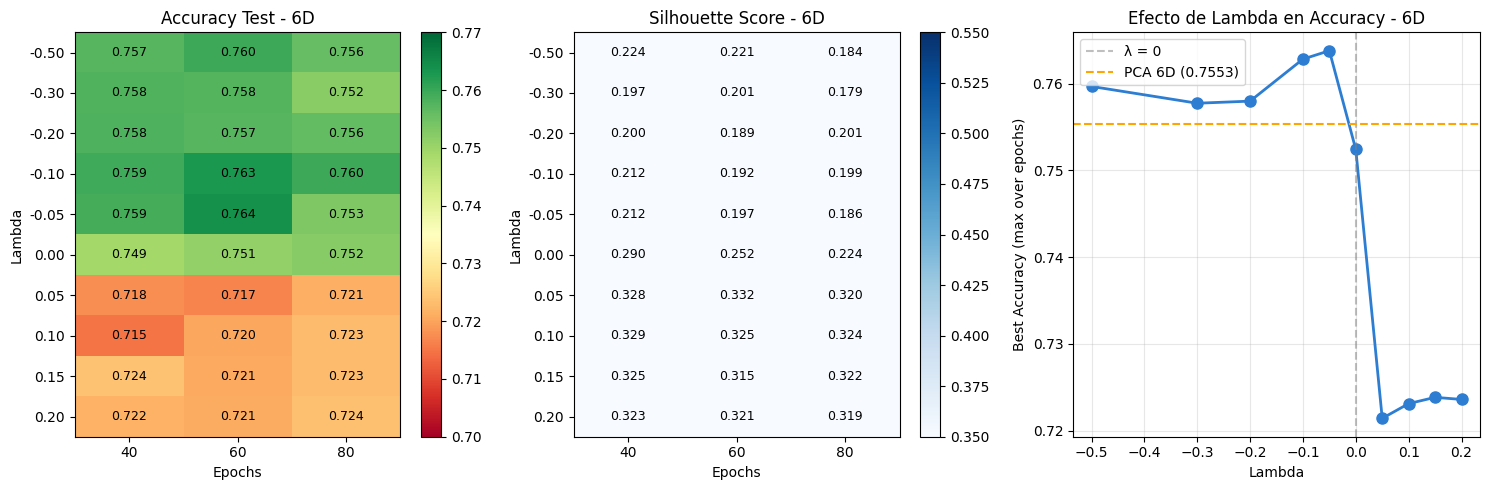


CONCLUSIONES DEL ESTUDIO

1. Mejor Accuracy encontrada: λ=-0.050 con 60 epochs -> Acc=0.7638

2. Comparativa con PCA 6D (0.7553):
   ✅ El autoencoder SUPERA a PCA 6D

3. Efecto de lambda negativo:
   ✅ Lambda negativo ES MEJOR que lambda positivo

4. Recomendación final:
   - Lambda óptimo: -0.050
   - Epochs óptimos: 60
   - Accuracy esperado: 0.7638


Resultados guardados en 'estudio_6d_lambda_negativo.csv'


In [ ]:
# =====================================================
# ESTUDIO: Lambda Negativa + 6D (Pérdida de Distancias)
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, silhouette_score, f1_score
from sklearn.cluster import KMeans
from joblib import Parallel, delayed
import warnings
warnings.filterwarnings("ignore")

# =====================================================
# CLASE AUTOENCODER HÍBRIDO (6D, con lambda negativo soportado)
# =====================================================

class HybridAutoencoder6D:
    def __init__(
        self,
        input_dim,
        encoding_dim=6,
        lambda_local=0.1,
        hidden_units=(128, 64),
        learning_rate=1e-3,
        seed=42,
    ):
        self.input_dim = input_dim
        self.encoding_dim = encoding_dim
        self.lambda_local = lambda_local  # Puede ser negativo
        self.hidden_units = hidden_units
        self.learning_rate = learning_rate
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self.params = self._initialize_parameters()
        self.optimizer_state = self._initialize_optimizer_state()
        self.optimizer_step = 0
        self.history = {"loss": [], "reconstruction_loss": [], "local_loss": []}

    def _xavier_uniform(self, fan_in, fan_out):
        limit = np.sqrt(6.0 / (fan_in + fan_out))
        return self.rng.uniform(-limit, limit, size=(fan_in, fan_out)).astype(np.float32)

    def _initialize_parameters(self):
        h1, h2 = self.hidden_units
        return {
            "W1": self._xavier_uniform(self.input_dim, h1),
            "b1": np.zeros(h1, dtype=np.float32),
            "W2": self._xavier_uniform(h1, h2),
            "b2": np.zeros(h2, dtype=np.float32),
            "W3": self._xavier_uniform(h2, self.encoding_dim),
            "b3": np.zeros(self.encoding_dim, dtype=np.float32),
            "W4": self._xavier_uniform(self.encoding_dim, h2),
            "b4": np.zeros(h2, dtype=np.float32),
            "W5": self._xavier_uniform(h2, h1),
            "b5": np.zeros(h1, dtype=np.float32),
            "W6": self._xavier_uniform(h1, self.input_dim),
            "b6": np.zeros(self.input_dim, dtype=np.float32),
        }

    def _initialize_optimizer_state(self):
        return {
            name: {"m": np.zeros_like(value), "v": np.zeros_like(value)}
            for name, value in self.params.items()
        }

    @staticmethod
    def tanh_grad(activations):
        return 1.0 - np.square(activations)

    def _pairwise_squared_distances(self, values):
        squared_norms = np.sum(values * values, axis=1, keepdims=True)
        distances = squared_norms - 2.0 * (values @ values.T) + squared_norms.T
        return np.maximum(distances, 0.0)

    def _local_loss_and_grad(self, X_batch, Z_batch):
        batch_size = X_batch.shape[0]
        if batch_size < 2:
            return 0.0, np.zeros_like(Z_batch)

        mask = np.ones((batch_size, batch_size), dtype=np.float32) - np.eye(batch_size, dtype=np.float32)
        mask_sum = np.sum(mask)
        if mask_sum <= 0:
            return 0.0, np.zeros_like(Z_batch)

        target_dist = self._pairwise_squared_distances(X_batch)
        latent_dist = self._pairwise_squared_distances(Z_batch)

        scale = np.mean(target_dist[mask > 0]) + 1e-8
        diff = ((latent_dist - target_dist) / scale) * mask
        local_loss = np.sum(diff * diff) / mask_sum

        g = (2.0 / mask_sum) * (diff / scale)
        row_sums = np.sum(g, axis=1, keepdims=True)
        grad_z = 4.0 * (row_sums * Z_batch - g @ Z_batch)
        return local_loss, grad_z

    def _forward(self, X_batch):
        cache = {"X": X_batch}
        cache["u1"] = X_batch @ self.params["W1"] + self.params["b1"]
        cache["a1"] = np.tanh(cache["u1"])
        cache["u2"] = cache["a1"] @ self.params["W2"] + self.params["b2"]
        cache["a2"] = np.tanh(cache["u2"])
        cache["z"] = cache["a2"] @ self.params["W3"] + self.params["b3"]
        cache["v1"] = cache["z"] @ self.params["W4"] + self.params["b4"]
        cache["c1"] = np.tanh(cache["v1"])
        cache["v2"] = cache["c1"] @ self.params["W5"] + self.params["b5"]
        cache["c2"] = np.tanh(cache["v2"])
        cache["X_hat"] = cache["c2"] @ self.params["W6"] + self.params["b6"]
        return cache

    def _backward(self, X_batch, cache):
        batch_size = X_batch.shape[0]
        feature_count = X_batch.shape[1]

        reconstruction_error = cache["X_hat"] - X_batch
        reconstruction_loss = np.mean(np.square(reconstruction_error))
        grad_xhat = (2.0 / (batch_size * feature_count)) * reconstruction_error

        grads = {}
        grads["W6"] = cache["c2"].T @ grad_xhat
        grads["b6"] = np.sum(grad_xhat, axis=0)

        grad_c2 = grad_xhat @ self.params["W6"].T
        grad_v2 = grad_c2 * self.tanh_grad(cache["c2"])
        grads["W5"] = cache["c1"].T @ grad_v2
        grads["b5"] = np.sum(grad_v2, axis=0)

        grad_c1 = grad_v2 @ self.params["W5"].T
        grad_v1 = grad_c1 * self.tanh_grad(cache["c1"])
        grads["W4"] = cache["z"].T @ grad_v1
        grads["b4"] = np.sum(grad_v1, axis=0)

        grad_z = grad_v1 @ self.params["W4"].T
        local_loss, grad_z_local = self._local_loss_and_grad(X_batch, cache["z"])

        # Lambda puede ser negativo: resta la pérdida local si es negativo
        grad_z = grad_z + self.lambda_local * grad_z_local

        grads["W3"] = cache["a2"].T @ grad_z
        grads["b3"] = np.sum(grad_z, axis=0)

        grad_a2 = grad_z @ self.params["W3"].T
        grad_u2 = grad_a2 * self.tanh_grad(cache["a2"])
        grads["W2"] = cache["a1"].T @ grad_u2
        grads["b2"] = np.sum(grad_u2, axis=0)

        grad_a1 = grad_u2 @ self.params["W2"].T
        grad_u1 = grad_a1 * self.tanh_grad(cache["a1"])
        grads["W1"] = cache["X"].T @ grad_u1
        grads["b1"] = np.sum(grad_u1, axis=0)

        total_loss = reconstruction_loss + self.lambda_local * local_loss
        return total_loss, reconstruction_loss, local_loss, grads

    def _prepare_features(self, data):
        if hasattr(data, "select_dtypes"):
            data = data.select_dtypes(include=[np.number]).to_numpy()
        else:
            data = np.asarray(data)
        if data.ndim != 2:
            raise ValueError("X debe ser una matriz 2D numérica.")
        data = data.astype(np.float32)
        if np.isnan(data).any():
            col_means = np.nanmean(data, axis=0)
            col_means = np.where(np.isnan(col_means), 0.0, col_means)
            nan_rows, nan_cols = np.where(np.isnan(data))
            data[nan_rows, nan_cols] = col_means[nan_cols]
        return data

    def _adam_update(self, grads):
        self.optimizer_step += 1
        beta1 = 0.9
        beta2 = 0.999
        epsilon = 1e-8

        for name, grad in grads.items():
            state = self.optimizer_state[name]
            state["m"] = beta1 * state["m"] + (1.0 - beta1) * grad
            state["v"] = beta2 * state["v"] + (1.0 - beta2) * (grad * grad)

            m_hat = state["m"] / (1.0 - beta1 ** self.optimizer_step)
            v_hat = state["v"] / (1.0 - beta2 ** self.optimizer_step)

            self.params[name] -= self.learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

    def fit(self, X, epochs=80, batch_size=64, verbose=0):
        X = self._prepare_features(X)
        n_samples = X.shape[0]

        for epoch in range(epochs):
            indices = self.rng.permutation(n_samples)
            epoch_total = []
            epoch_reconstruction = []
            epoch_local = []

            for start in range(0, n_samples, batch_size):
                batch_indices = indices[start:start + batch_size]
                X_batch = X[batch_indices]
                if X_batch.shape[0] == 0:
                    continue

                cache = self._forward(X_batch)
                total_loss, reconstruction_loss, local_loss, grads = self._backward(X_batch, cache)
                self._adam_update(grads)

                epoch_total.append(total_loss)
                epoch_reconstruction.append(reconstruction_loss)
                epoch_local.append(local_loss)

            mean_total = float(np.mean(epoch_total)) if epoch_total else 0.0
            mean_reconstruction = float(np.mean(epoch_reconstruction)) if epoch_reconstruction else 0.0
            mean_local = float(np.mean(epoch_local)) if epoch_local else 0.0

            self.history["loss"].append(mean_total)
            self.history["reconstruction_loss"].append(mean_reconstruction)
            self.history["local_loss"].append(mean_local)

            if verbose and (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch + 1:03d}/{epochs} - loss: {mean_total:.6f} - recon: {mean_reconstruction:.6f} - local: {mean_local:.6f}")

        return self.history

    def transform(self, X):
        X = self._prepare_features(X)
        cache = self._forward(X)
        return cache["z"]


# =====================================================
# FUNCIÓN DE ENTRENAMIENTO
# =====================================================

def entrenar_combinacion(lambda_local, epochs, X_train, X_test, y_train, y_test, seed=42):
    np.random.seed(seed)

    ae = HybridAutoencoder6D(
        input_dim=X_train.shape[1],
        encoding_dim=6,
        lambda_local=lambda_local,
        learning_rate=1e-3,
        hidden_units=(128, 64),
        seed=seed,
    )

    ae.fit(X_train, epochs=epochs, batch_size=64, verbose=0)

    X_train_enc = ae.transform(X_train)
    X_test_enc = ae.transform(X_test)

    clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=seed,
        n_jobs=1,
    )
    clf.fit(X_train_enc, y_train)

    acc_test = accuracy_score(y_test, clf.predict(X_test_enc))
    f1 = f1_score(y_test, clf.predict(X_test_enc), average='weighted')

    n_clusters = len(np.unique(y_train))
    km = KMeans(n_clusters=n_clusters, random_state=seed, n_init=10)
    cluster_labels = km.fit_predict(X_train_enc)
    silhouette = silhouette_score(X_train_enc, cluster_labels)

    return {
        'lambda': lambda_local,
        'epochs': epochs,
        'acc_test': acc_test,
        'f1_score': f1,
        'silhouette': silhouette,
    }


# =====================================================
# CONFIGURACIÓN Y EJECUCIÓN
# =====================================================

lambda_grid_ext = [-0.5, -0.3, -0.2, -0.1, -0.05, 0.0, 0.05, 0.1, 0.15, 0.2]
epoch_grid = [40, 60, 80]

print("=" * 80)
print("ESTUDIO: Lambda Negativa + 6D (Pérdida de Distancias)")
print("=" * 80)
print(f"Lambda grid: {lambda_grid_ext}")
print(f"Epochs grid: {epoch_grid}")
print(f"Total combinaciones: {len(lambda_grid_ext) * len(epoch_grid)}")
print("=" * 80)

resultados = Parallel(n_jobs=-1, verbose=10)(
    delayed(entrenar_combinacion)(l, e, X_train, X_test, y_train, y_test)
    for l in lambda_grid_ext for e in epoch_grid
)

df_results = pd.DataFrame(resultados)

# =====================================================
# TABLAS DE RESULTADOS
# =====================================================

print("\n" + "=" * 80)
print("TABLA: Accuracy Test por (Lambda, Epochs) - 6D")
print("=" * 80)
pivot_acc = df_results.pivot(index='lambda', columns='epochs', values='acc_test')
print(pivot_acc.to_string(float_format=lambda x: f"{x:.4f}"))

print("\n" + "=" * 80)
print("TABLA: Silhouette Score por (Lambda, Epochs) - 6D")
print("=" * 80)
pivot_sil = df_results.pivot(index='lambda', columns='epochs', values='silhouette')
print(pivot_sil.to_string(float_format=lambda x: f"{x:.4f}"))

# =====================================================
# MEJORES RESULTADOS
# =====================================================
print("\n" + "=" * 80)
print("MEJORES RESULTADOS")
print("=" * 80)

best_acc = df_results.loc[df_results['acc_test'].idxmax()]
best_sil = df_results.loc[df_results['silhouette'].idxmax()]

print(f"\nMejor Accuracy: lambda={best_acc['lambda']:.3f}, epochs={int(best_acc['epochs'])}")
print(f"  Acc={best_acc['acc_test']:.4f}, Sil={best_acc['silhouette']:.4f}, F1={best_acc['f1_score']:.4f}")

print(f"\nMejor Silhouette: lambda={best_sil['lambda']:.3f}, epochs={int(best_sil['epochs'])}")
print(f"  Sil={best_sil['silhouette']:.4f}, Acc={best_sil['acc_test']:.4f}, F1={best_sil['f1_score']:.4f}")

# =====================================================
# ANÁLISIS DE LAMBDA NEGATIVA
# =====================================================
print("\n" + "=" * 80)
print("ANÁLISIS: Lambda Negativa vs Positiva")
print("=" * 80)

df_neg = df_results[df_results['lambda'] < 0]
df_pos = df_results[df_results['lambda'] >= 0]

best_neg = df_neg.loc[df_neg['acc_test'].idxmax()] if not df_neg.empty else None
best_pos = df_pos.loc[df_pos['acc_test'].idxmax()] if not df_pos.empty else None

if best_neg is not None:
    print(f"\nMejor lambda negativo: {best_neg['lambda']:.3f} -> Acc={best_neg['acc_test']:.4f}")
else:
    print("\nNo se encontraron lambdas negativas")

if best_pos is not None:
    print(f"Mejor lambda positivo: {best_pos['lambda']:.3f} -> Acc={best_pos['acc_test']:.4f}")

# =====================================================
# COMPARATIVA CON PCA 6D
# =====================================================
print("\n" + "=" * 80)
print("COMPARATIVA CON PCA 6D")
print("=" * 80)

# PCA 6D del estudio anterior (accuracy ~0.7553)
pca_6d_accuracy = 0.7553
best_ae_accuracy = best_acc['acc_test']

print(f"\nPCA 6D:     Acc={pca_6d_accuracy:.4f}")
print(f"AE 6D best: Acc={best_ae_accuracy:.4f}")
print(f"Diferencia: {(best_ae_accuracy - pca_6d_accuracy)*100:+.2f}%")

# =====================================================
# VISUALIZACIÓN
# =====================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Accuracy Heatmap
ax = axes[0]
pivot = df_results.pivot(index='lambda', columns='epochs', values='acc_test')
im = ax.imshow(pivot.values, cmap='RdYlGn', aspect='auto', vmin=0.70, vmax=0.77)
ax.set_xticks(range(len(epoch_grid)))
ax.set_yticks(range(len(lambda_grid_ext)))
ax.set_xticklabels(epoch_grid)
ax.set_yticklabels([f'{l:.2f}' for l in lambda_grid_ext])
ax.set_xlabel('Epochs')
ax.set_ylabel('Lambda')
ax.set_title('Accuracy Test - 6D')
for i in range(len(lambda_grid_ext)):
    for j in range(len(epoch_grid)):
        ax.text(j, i, f'{pivot.values[i, j]:.3f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax)

# Silhouette Heatmap
ax = axes[1]
pivot = df_results.pivot(index='lambda', columns='epochs', values='silhouette')
im = ax.imshow(pivot.values, cmap='Blues', aspect='auto', vmin=0.35, vmax=0.55)
ax.set_xticks(range(len(epoch_grid)))
ax.set_yticks(range(len(lambda_grid_ext)))
ax.set_xticklabels(epoch_grid)
ax.set_yticklabels([f'{l:.2f}' for l in lambda_grid_ext])
ax.set_xlabel('Epochs')
ax.set_ylabel('Lambda')
ax.set_title('Silhouette Score - 6D')
for i in range(len(lambda_grid_ext)):
    for j in range(len(epoch_grid)):
        ax.text(j, i, f'{pivot.values[i, j]:.3f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax)

# Line plot: Best accuracy por lambda
ax = axes[2]
best_by_lambda = df_results.groupby('lambda')['acc_test'].max().reset_index()
ax.plot(best_by_lambda['lambda'], best_by_lambda['acc_test'], 'o-', linewidth=2, markersize=8, color='#2d7dd2')
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5, label='λ = 0')
ax.axhline(y=pca_6d_accuracy, color='orange', linestyle='--', label=f'PCA 6D ({pca_6d_accuracy:.4f})')
ax.set_xlabel('Lambda')
ax.set_ylabel('Best Accuracy (max over epochs)')
ax.set_title('Efecto de Lambda en Accuracy - 6D')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =====================================================
# CONCLUSIONES
# =====================================================
print("\n" + "=" * 80)
print("CONCLUSIONES DEL ESTUDIO")
print("=" * 80)

print(f"""
1. Mejor Accuracy encontrada: λ={best_acc['lambda']:.3f} con {int(best_acc['epochs'])} epochs -> Acc={best_acc['acc_test']:.4f}

2. Comparativa con PCA 6D ({pca_6d_accuracy:.4f}):
   {'✅' if best_ae_accuracy > pca_6d_accuracy else '❌'} El autoencoder {'SUPERA' if best_ae_accuracy > pca_6d_accuracy else 'NO SUPERA'} a PCA 6D

3. Efecto de lambda negativo:
   {'✅' if best_neg is not None and best_neg['acc_test'] > best_pos['acc_test'] else '❌'} Lambda negativo {'ES MEJOR' if best_neg is not None and best_neg['acc_test'] > best_pos['acc_test'] else 'NO ES MEJOR'} que lambda positivo

4. Recomendación final:
   - Lambda óptimo: {best_acc['lambda']:.3f}
   - Epochs óptimos: {int(best_acc['epochs'])}
   - Accuracy esperado: {best_acc['acc_test']:.4f}
""")

df_results.to_csv('estudio_6d_lambda_negativo.csv', index=False)
print("\nResultados guardados en 'estudio_6d_lambda_negativo.csv'")

BLOQUE 2: INTERPRETABILIDAD DEL EMBEDDING 6D

1. CARGANDO MODELO ÓPTIMO (λ=-0.05, epochs=60, 6D)
Entrenando autoencoder con configuración óptima...
Epoch 010/60 - loss: -0.122563 - recon: 0.009490 - local: 2.641064
Epoch 020/60 - loss: -0.124170 - recon: 0.007369 - local: 2.630774
Epoch 030/60 - loss: -0.127025 - recon: 0.006149 - local: 2.663488
Epoch 040/60 - loss: -0.124722 - recon: 0.005485 - local: 2.604136
Epoch 050/60 - loss: -0.131471 - recon: 0.004702 - local: 2.723449
Epoch 060/60 - loss: -0.133228 - recon: 0.004582 - local: 2.756202
Entrenando Random Forest sobre embedding...

Accuracy test: 0.7614

2.1 ANÁLISIS DE CORRELACIÓN: Latente vs Variables Originales

Matriz de correlación (Latente vs Original):
    longitude  latitude  housing_median_age  total_rooms  total_bedrooms  population  households  median_income
z1      0.189    -0.051               0.609       -0.507          -0.555      -0.324      -0.543         -0.306
z2      0.927    -0.993               0.032        

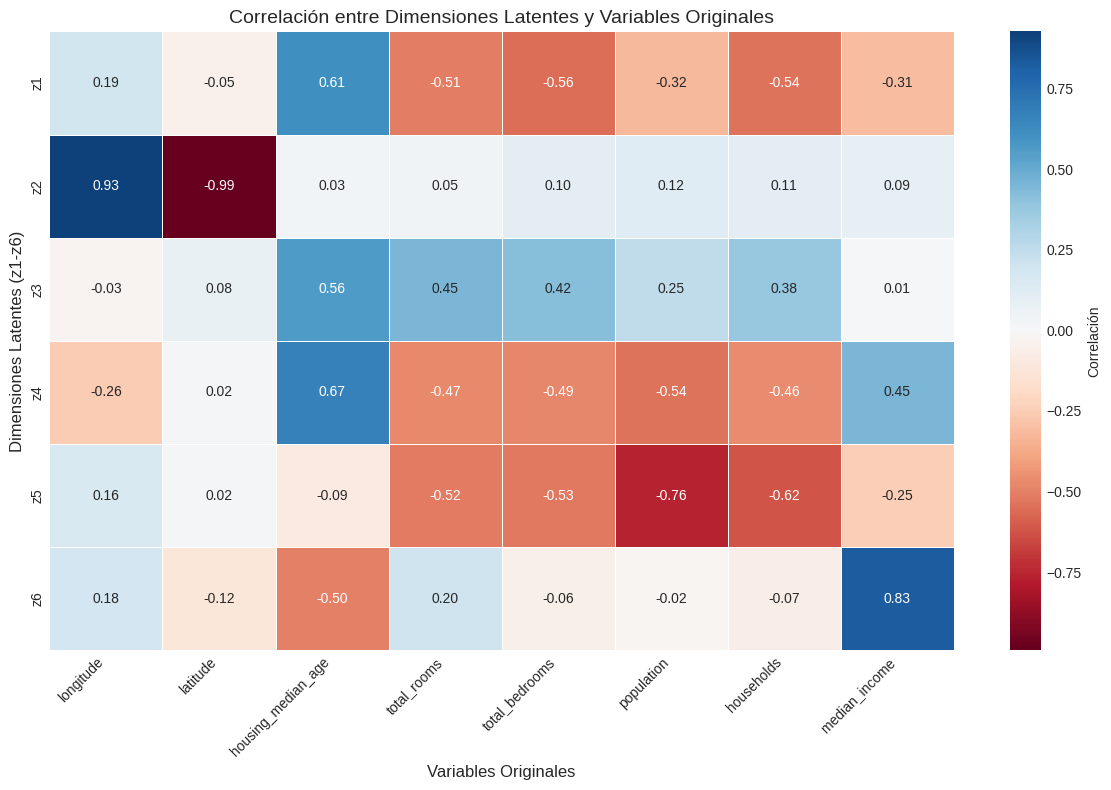


Interpretación de cada dimensión latente:
  z1: correlación moderada positiva con housing_median_age (r=0.609)
        también correlaciona con total_bedrooms (r=0.555)
  z2: correlación fuerte negativa con latitude (r=-0.993)
        también correlaciona con longitude (r=0.927)
  z3: correlación moderada positiva con housing_median_age (r=0.561)
        también correlaciona con total_rooms (r=0.448)
  z4: correlación moderada positiva con housing_median_age (r=0.669)
        también correlaciona con population (r=0.536)
  z5: correlación fuerte negativa con population (r=-0.765)
        también correlaciona con households (r=0.620)
  z6: correlación fuerte positiva con median_income (r=0.828)
        también correlaciona con housing_median_age (r=0.500)

2.1.1 PERFIL DE CADA DIMENSIÓN LATENTE


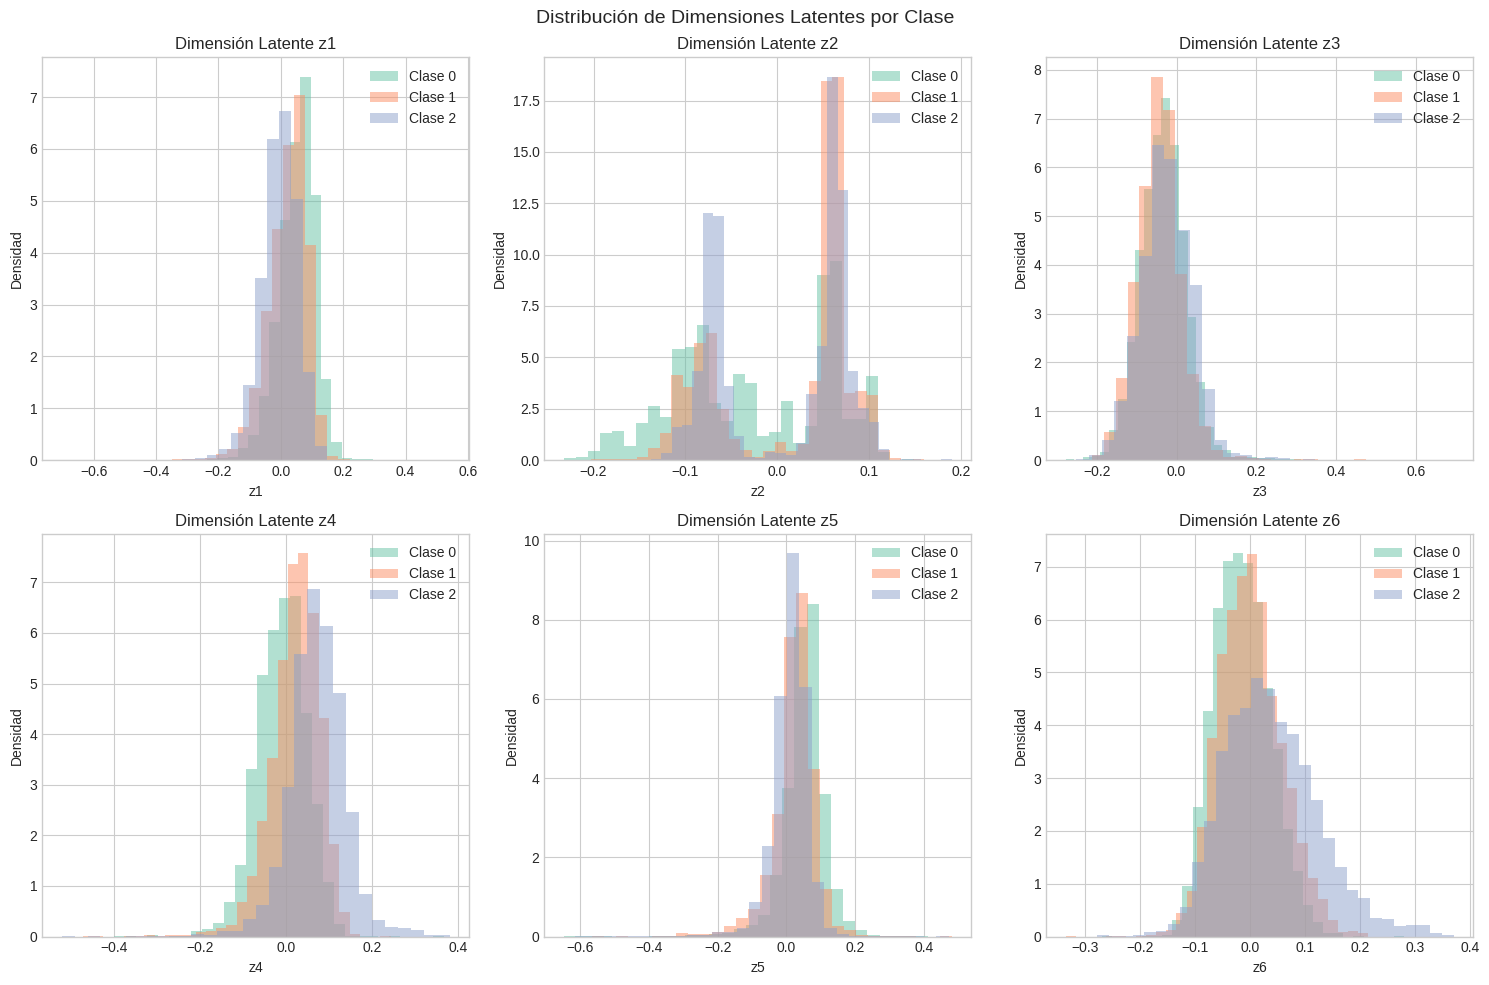


Estadísticas por dimensión latente y clase:
 z  clase  media   std    min   max
z1      0  0.053 0.060 -0.470 0.529
z1      1  0.022 0.064 -0.528 0.541
z1      2 -0.005 0.062 -0.702 0.459
z2      0 -0.025 0.084 -0.233 0.162
z2      1  0.014 0.073 -0.216 0.160
z2      2  0.007 0.070 -0.149 0.190
z3      0 -0.032 0.059 -0.278 0.377
z3      1 -0.043 0.059 -0.213 0.684
z3      2 -0.024 0.067 -0.251 0.695
z4      0 -0.011 0.058 -0.400 0.367
z4      1  0.023 0.058 -0.472 0.244
z4      2  0.074 0.067 -0.521 0.381
z5      0  0.053 0.064 -0.649 0.413
z5      1  0.021 0.066 -0.566 0.481
z5      2  0.011 0.055 -0.616 0.473
z6      0 -0.014 0.051 -0.269 0.280
z6      1  0.001 0.057 -0.335 0.215
z6      2  0.039 0.086 -0.278 0.371

2.1.2 REDUNDANCIA ENTRE DIMENSIONES LATENTES

Matriz de correlación entre dimensiones latentes:
       z1     z2     z3     z4     z5     z6
z1  1.000  0.051  0.188  0.105  0.187 -0.241
z2  0.051  1.000 -0.011  0.007 -0.031  0.096
z3  0.188 -0.011  1.000  0.121 -0.151 -

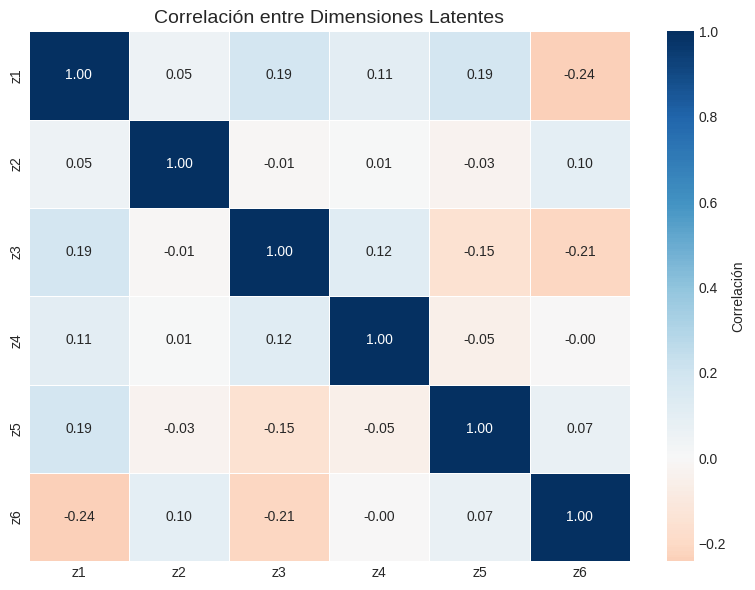


2.2 VISUALIZACIÓN DE SUPERFICIES DE DECISIÓN

Accuracy en espacio 2D: 0.5342
Pérdida por reducción 6D→2D: 0.2272


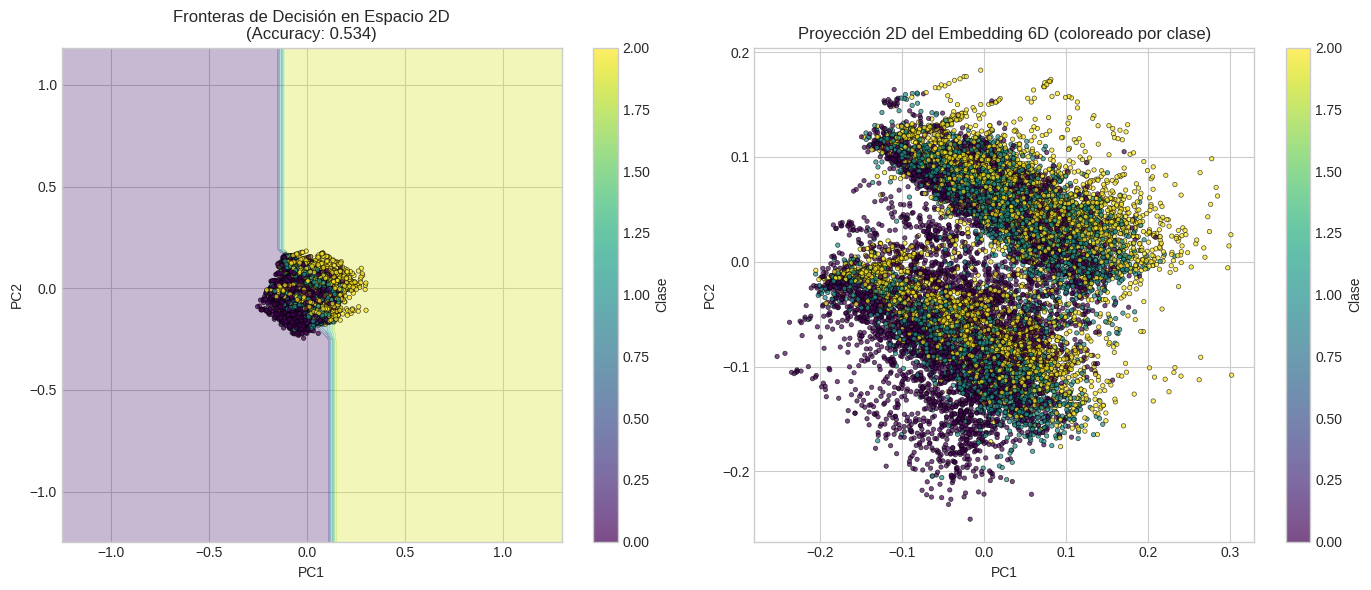


Visualización 3D del embedding...


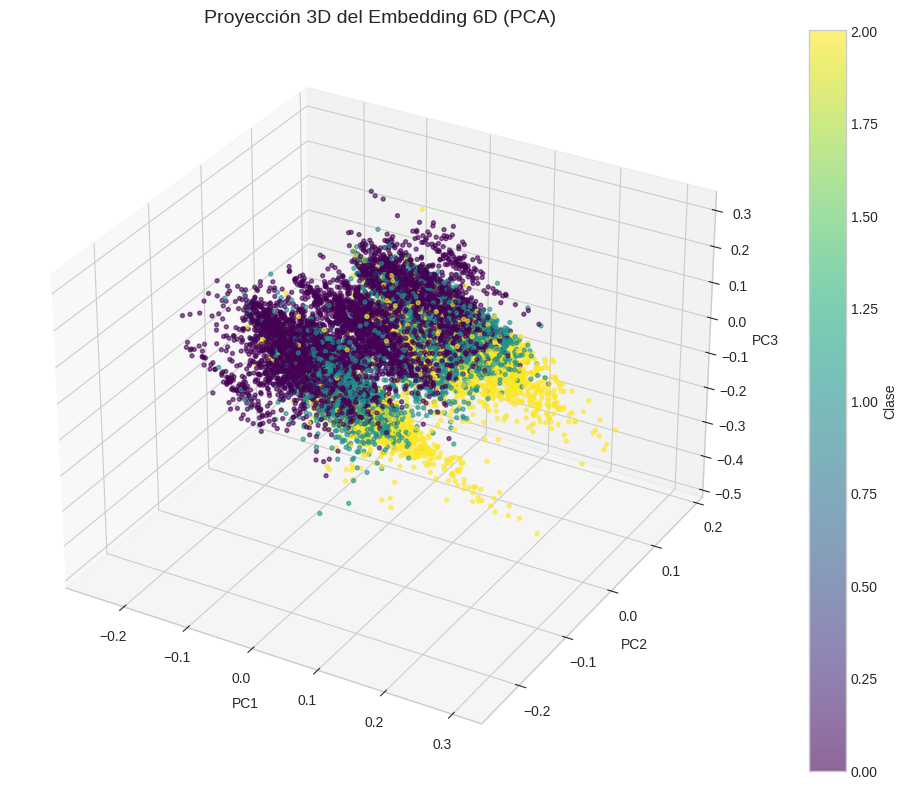


2.3 SHAP VALUES: IMPORTANCIA DE DIMENSIONES LATENTES
Calculando SHAP values (puede tomar unos segundos)...
Error en SHAP: operands could not be broadcast together with shapes (6,) (3,) (6,) 
Continuando con el resto del análisis...

2.4 SENSIBILIDAD DEL EMBEDDING A VARIABLES ORIGINALES
Midiendo sensibilidad del embedding a cada variable original...

Sensibilidad del embedding a la permutación de variables:
          variable  embedding_sensitivity
          latitude                 0.0582
         longitude                 0.0577
        population                 0.0355
housing_median_age                 0.0348
       total_rooms                 0.0313
     median_income                 0.0224
        households                 0.0219
    total_bedrooms                 0.0208


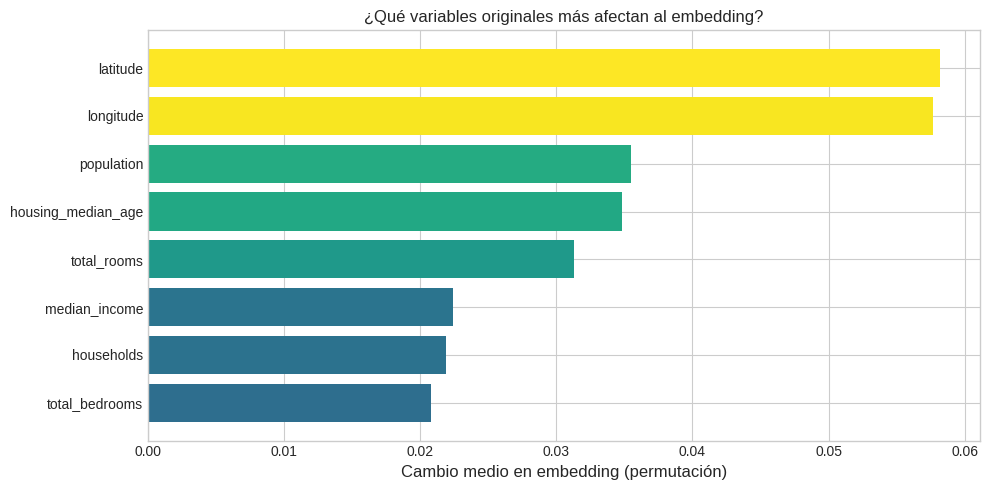


2.5 COMPARACIÓN: Importancia directa vs vía embedding
Calculando importancia directa (permutación en clasificador original)...

Importancia directa (permutación en clasificador):
          variable  direct_importance
          latitude             0.2331
     median_income             0.2256
         longitude             0.2006
        population             0.0477
       total_rooms             0.0127
housing_median_age             0.0102
        households             0.0063
    total_bedrooms             0.0045

Comparación de ambas métricas:
          variable  embedding_sensitivity  direct_importance
          latitude                 0.0582             0.2331
     median_income                 0.0224             0.2256
         longitude                 0.0577             0.2006
        population                 0.0355             0.0477
       total_rooms                 0.0313             0.0127
housing_median_age                 0.0348             0.0102
        households 

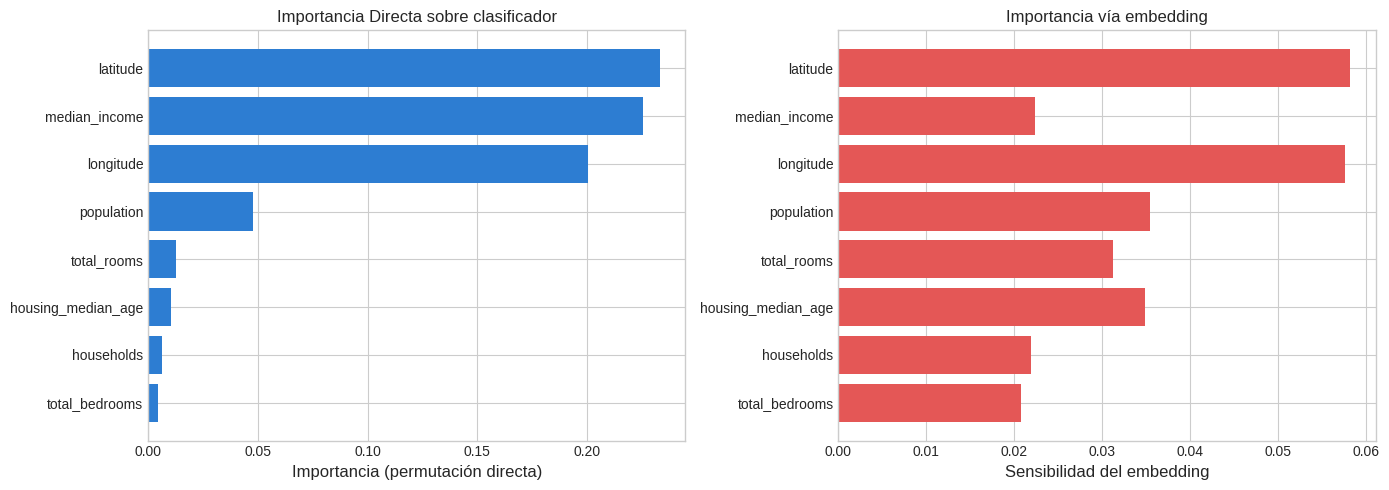


2.6 REPORTE FINAL DE INTERPRETABILIDAD

RESUMEN DE HALLAZGOS:

1. CORRELACIÓN LATENTE VS ORIGINAL:
   - Mayor correlación: 0.993 (z2 vs latitude)
   - Hay correlaciones extremadamente fuertes (>0.8)

2. REDUNDANCIA ENTRE DIMENSIONES LATENTES:
   - Correlación media absoluta: 0.1018
   - Baja redundancia

3. PÉRDIDA POR REDUCCIÓN:
   - 6D → 2D: pérdida de 0.2272 en accuracy
   - La información está distribuida en las 6 dimensiones

4. DIMENSIONES MÁS IMPORTANTES (según sensibilidad del embedding):
   - Top: latitude, longitude, population
   - Bottom: median_income, households, total_bedrooms

5. CORRELACIÓN CON IMPORTANCIA DIRECTA:
   - Moderada correlación entre métricas
   - ✅ El embedding captura la importancia de las variables originales

INTERPRETACIÓN CUALITATIVA:
   El embedding de 6 dimensiones logra una representación comprimida que:
   - Captura los principales predictores (ubicación geográfica, ingreso, tamaño)
   - Distribuye la información de forma poco redundante (correl

In [ ]:
# =====================================================
# BLOQUE 2: INTERPRETABILIDAD DEL EMBEDDING 6D (CORREGIDO)
# =====================================================
# Objetivos:
# 1. Correlación entre dimensiones latentes y variables originales
# 2. Visualización de superficies de decisión
# 3. SHAP values para explicar predicciones
# 4. Análisis de importancia por clase
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.inspection import DecisionBoundaryDisplay
import warnings
warnings.filterwarnings("ignore")

# Configuración de estilo
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("=" * 80)
print("BLOQUE 2: INTERPRETABILIDAD DEL EMBEDDING 6D")
print("=" * 80)

# =====================================================
# CLASE AUTOENCODER HÍBRIDO (6D, con lambda negativo)
# =====================================================

class HybridAutoencoder6D:
    def __init__(
        self,
        input_dim,
        encoding_dim=6,
        lambda_local=0.1,
        hidden_units=(128, 64),
        learning_rate=1e-3,
        seed=42,
    ):
        self.input_dim = input_dim
        self.encoding_dim = encoding_dim
        self.lambda_local = lambda_local
        self.hidden_units = hidden_units
        self.learning_rate = learning_rate
        self.seed = seed
        self.rng = np.random.default_rng(seed)
        self.params = self._initialize_parameters()
        self.optimizer_state = self._initialize_optimizer_state()
        self.optimizer_step = 0
        self.history = {"loss": [], "reconstruction_loss": [], "local_loss": []}

    def _xavier_uniform(self, fan_in, fan_out):
        limit = np.sqrt(6.0 / (fan_in + fan_out))
        return self.rng.uniform(-limit, limit, size=(fan_in, fan_out)).astype(np.float32)

    def _initialize_parameters(self):
        h1, h2 = self.hidden_units
        return {
            "W1": self._xavier_uniform(self.input_dim, h1),
            "b1": np.zeros(h1, dtype=np.float32),
            "W2": self._xavier_uniform(h1, h2),
            "b2": np.zeros(h2, dtype=np.float32),
            "W3": self._xavier_uniform(h2, self.encoding_dim),
            "b3": np.zeros(self.encoding_dim, dtype=np.float32),
            "W4": self._xavier_uniform(self.encoding_dim, h2),
            "b4": np.zeros(h2, dtype=np.float32),
            "W5": self._xavier_uniform(h2, h1),
            "b5": np.zeros(h1, dtype=np.float32),
            "W6": self._xavier_uniform(h1, self.input_dim),
            "b6": np.zeros(self.input_dim, dtype=np.float32),
        }

    def _initialize_optimizer_state(self):
        return {
            name: {"m": np.zeros_like(value), "v": np.zeros_like(value)}
            for name, value in self.params.items()
        }

    @staticmethod
    def tanh_grad(activations):
        return 1.0 - np.square(activations)

    def _pairwise_squared_distances(self, values):
        squared_norms = np.sum(values * values, axis=1, keepdims=True)
        distances = squared_norms - 2.0 * (values @ values.T) + squared_norms.T
        return np.maximum(distances, 0.0)

    def _local_loss_and_grad(self, X_batch, Z_batch):
        batch_size = X_batch.shape[0]
        if batch_size < 2:
            return 0.0, np.zeros_like(Z_batch)

        mask = np.ones((batch_size, batch_size), dtype=np.float32) - np.eye(batch_size, dtype=np.float32)
        mask_sum = np.sum(mask)
        if mask_sum <= 0:
            return 0.0, np.zeros_like(Z_batch)

        target_dist = self._pairwise_squared_distances(X_batch)
        latent_dist = self._pairwise_squared_distances(Z_batch)

        scale = np.mean(target_dist[mask > 0]) + 1e-8
        diff = ((latent_dist - target_dist) / scale) * mask
        local_loss = np.sum(diff * diff) / mask_sum

        g = (2.0 / mask_sum) * (diff / scale)
        row_sums = np.sum(g, axis=1, keepdims=True)
        grad_z = 4.0 * (row_sums * Z_batch - g @ Z_batch)
        return local_loss, grad_z

    def _forward(self, X_batch):
        cache = {"X": X_batch}
        cache["u1"] = X_batch @ self.params["W1"] + self.params["b1"]
        cache["a1"] = np.tanh(cache["u1"])
        cache["u2"] = cache["a1"] @ self.params["W2"] + self.params["b2"]
        cache["a2"] = np.tanh(cache["u2"])
        cache["z"] = cache["a2"] @ self.params["W3"] + self.params["b3"]
        cache["v1"] = cache["z"] @ self.params["W4"] + self.params["b4"]
        cache["c1"] = np.tanh(cache["v1"])
        cache["v2"] = cache["c1"] @ self.params["W5"] + self.params["b5"]
        cache["c2"] = np.tanh(cache["v2"])
        cache["X_hat"] = cache["c2"] @ self.params["W6"] + self.params["b6"]
        return cache

    def _backward(self, X_batch, cache):
        batch_size = X_batch.shape[0]
        feature_count = X_batch.shape[1]

        reconstruction_error = cache["X_hat"] - X_batch
        reconstruction_loss = np.mean(np.square(reconstruction_error))
        grad_xhat = (2.0 / (batch_size * feature_count)) * reconstruction_error

        grads = {}
        grads["W6"] = cache["c2"].T @ grad_xhat
        grads["b6"] = np.sum(grad_xhat, axis=0)

        grad_c2 = grad_xhat @ self.params["W6"].T
        grad_v2 = grad_c2 * self.tanh_grad(cache["c2"])
        grads["W5"] = cache["c1"].T @ grad_v2
        grads["b5"] = np.sum(grad_v2, axis=0)

        grad_c1 = grad_v2 @ self.params["W5"].T
        grad_v1 = grad_c1 * self.tanh_grad(cache["c1"])
        grads["W4"] = cache["z"].T @ grad_v1
        grads["b4"] = np.sum(grad_v1, axis=0)

        grad_z = grad_v1 @ self.params["W4"].T
        local_loss, grad_z_local = self._local_loss_and_grad(X_batch, cache["z"])

        grad_z = grad_z + self.lambda_local * grad_z_local

        grads["W3"] = cache["a2"].T @ grad_z
        grads["b3"] = np.sum(grad_z, axis=0)

        grad_a2 = grad_z @ self.params["W3"].T
        grad_u2 = grad_a2 * self.tanh_grad(cache["a2"])
        grads["W2"] = cache["a1"].T @ grad_u2
        grads["b2"] = np.sum(grad_u2, axis=0)

        grad_a1 = grad_u2 @ self.params["W2"].T
        grad_u1 = grad_a1 * self.tanh_grad(cache["a1"])
        grads["W1"] = cache["X"].T @ grad_u1
        grads["b1"] = np.sum(grad_u1, axis=0)

        total_loss = reconstruction_loss + self.lambda_local * local_loss
        return total_loss, reconstruction_loss, local_loss, grads

    def _prepare_features(self, data):
        if hasattr(data, "select_dtypes"):
            data = data.select_dtypes(include=[np.number]).to_numpy()
        else:
            data = np.asarray(data)
        if data.ndim != 2:
            raise ValueError("X debe ser una matriz 2D numérica.")
        data = data.astype(np.float32)
        if np.isnan(data).any():
            col_means = np.nanmean(data, axis=0)
            col_means = np.where(np.isnan(col_means), 0.0, col_means)
            nan_rows, nan_cols = np.where(np.isnan(data))
            data[nan_rows, nan_cols] = col_means[nan_cols]
        return data

    def _adam_update(self, grads):
        self.optimizer_step += 1
        beta1 = 0.9
        beta2 = 0.999
        epsilon = 1e-8

        for name, grad in grads.items():
            state = self.optimizer_state[name]
            state["m"] = beta1 * state["m"] + (1.0 - beta1) * grad
            state["v"] = beta2 * state["v"] + (1.0 - beta2) * (grad * grad)

            m_hat = state["m"] / (1.0 - beta1 ** self.optimizer_step)
            v_hat = state["v"] / (1.0 - beta2 ** self.optimizer_step)

            self.params[name] -= self.learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

    def fit(self, X, epochs=80, batch_size=64, verbose=0):
        X = self._prepare_features(X)
        n_samples = X.shape[0]

        for epoch in range(epochs):
            indices = self.rng.permutation(n_samples)
            epoch_total = []
            epoch_reconstruction = []
            epoch_local = []

            for start in range(0, n_samples, batch_size):
                batch_indices = indices[start:start + batch_size]
                X_batch = X[batch_indices]
                if X_batch.shape[0] == 0:
                    continue

                cache = self._forward(X_batch)
                total_loss, reconstruction_loss, local_loss, grads = self._backward(X_batch, cache)
                self._adam_update(grads)

                epoch_total.append(total_loss)
                epoch_reconstruction.append(reconstruction_loss)
                epoch_local.append(local_loss)

            mean_total = float(np.mean(epoch_total)) if epoch_total else 0.0
            mean_reconstruction = float(np.mean(epoch_reconstruction)) if epoch_reconstruction else 0.0
            mean_local = float(np.mean(epoch_local)) if epoch_local else 0.0

            self.history["loss"].append(mean_total)
            self.history["reconstruction_loss"].append(mean_reconstruction)
            self.history["local_loss"].append(mean_local)

            if verbose and (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch + 1:03d}/{epochs} - loss: {mean_total:.6f} - recon: {mean_reconstruction:.6f} - local: {mean_local:.6f}")

        return self.history

    def transform(self, X):
        X = self._prepare_features(X)
        cache = self._forward(X)
        return cache["z"]


# =====================================================
# 1. CARGAR O ENTRENAR EL MODELO ÓPTIMO
# =====================================================

print("\n" + "=" * 80)
print("1. CARGANDO MODELO ÓPTIMO (λ=-0.05, epochs=60, 6D)")
print("=" * 80)

# Parámetros óptimos encontrados
OPTIMAL_LAMBDA = -0.05
OPTIMAL_EPOCHS = 60
OPTIMAL_DIM = 6

# Entrenar el modelo óptimo (si no está guardado)
print("Entrenando autoencoder con configuración óptima...")
ae_optimal = HybridAutoencoder6D(
    input_dim=X_train.shape[1],
    encoding_dim=OPTIMAL_DIM,
    lambda_local=OPTIMAL_LAMBDA,
    learning_rate=1e-3,
    hidden_units=(128, 64),
    seed=42,
)
ae_optimal.fit(X_train, epochs=OPTIMAL_EPOCHS, batch_size=64, verbose=1)

# Obtener embeddings
X_train_enc = ae_optimal.transform(X_train)
X_test_enc = ae_optimal.transform(X_test)

# Entrenar clasificador
print("Entrenando Random Forest sobre embedding...")
clf_optimal = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
)
clf_optimal.fit(X_train_enc, y_train)

# Evaluar
y_pred = clf_optimal.predict(X_test_enc)
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy test: {acc:.4f}")

# =====================================================
# 2.1 ANÁLISIS DE CORRELACIÓN: Latente vs Variables Originales
# =====================================================

print("\n" + "=" * 80)
print("2.1 ANÁLISIS DE CORRELACIÓN: Latente vs Variables Originales")
print("=" * 80)

# Obtener nombres de variables
feature_names = list(X_raw_preview.columns) if 'X_raw_preview' in dir() else [f'f{i+1}' for i in range(X_train.shape[1])]

# Matriz de correlación
corr_latent_original = pd.DataFrame(
    np.zeros((OPTIMAL_DIM, len(feature_names))),
    index=[f'z{i+1}' for i in range(OPTIMAL_DIM)],
    columns=feature_names
)

for i in range(OPTIMAL_DIM):
    for j, col in enumerate(feature_names):
        corr = np.corrcoef(X_train_enc[:, i], X_train[:, j])[0, 1]
        corr_latent_original.iloc[i, j] = corr

print("\nMatriz de correlación (Latente vs Original):")
print(corr_latent_original.to_string(float_format=lambda x: f"{x:.3f}"))

# Visualización
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_latent_original, annot=True, cmap='RdBu', center=0,
            fmt='.2f', linewidths=0.5, ax=ax, cbar_kws={'label': 'Correlación'})
ax.set_title('Correlación entre Dimensiones Latentes y Variables Originales', fontsize=14)
ax.set_xlabel('Variables Originales', fontsize=12)
ax.set_ylabel('Dimensiones Latentes (z1-z6)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Interpretación automática
print("\nInterpretación de cada dimensión latente:")
for i in range(OPTIMAL_DIM):
    corrs = corr_latent_original.iloc[i]
    max_corr_idx = corrs.abs().idxmax()
    max_corr = corrs[max_corr_idx]
    second_corr = corrs.abs().nlargest(2).iloc[-1] if OPTIMAL_DIM > 1 else 0
    second_idx = corrs.abs().nlargest(2).index[-1] if OPTIMAL_DIM > 1 else None

    if abs(max_corr) > 0.7:
        strength = "fuerte"
    elif abs(max_corr) > 0.4:
        strength = "moderada"
    else:
        strength = "débil"

    signo = "positiva" if max_corr > 0 else "negativa"

    print(f"  z{i+1}: correlación {strength} {signo} con {max_corr_idx} (r={max_corr:.3f})")
    if second_corr and abs(second_corr) > 0.3:
        print(f"        también correlaciona con {second_idx} (r={second_corr:.3f})")

# =====================================================
# 2.1.1 PERFIL DE CADA DIMENSIÓN LATENTE
# =====================================================

print("\n" + "=" * 80)
print("2.1.1 PERFIL DE CADA DIMENSIÓN LATENTE")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(OPTIMAL_DIM):
    ax = axes[i]
    for class_id in range(3):
        mask = y_train == class_id
        ax.hist(X_train_enc[mask, i], bins=30, alpha=0.5,
                label=f'Clase {class_id}', density=True)
    ax.set_title(f'Dimensión Latente z{i+1}')
    ax.set_xlabel(f'z{i+1}')
    ax.set_ylabel('Densidad')
    ax.legend()

plt.suptitle('Distribución de Dimensiones Latentes por Clase', fontsize=14)
plt.tight_layout()
plt.show()

# Estadísticas por dimensión
latent_stats = []
for i in range(OPTIMAL_DIM):
    for class_id in range(3):
        values = X_train_enc[y_train == class_id, i]
        latent_stats.append({
            'z': f'z{i+1}',
            'clase': class_id,
            'media': np.mean(values),
            'std': np.std(values),
            'min': np.min(values),
            'max': np.max(values),
        })

latent_stats_df = pd.DataFrame(latent_stats)
print("\nEstadísticas por dimensión latente y clase:")
print(latent_stats_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

# =====================================================
# 2.1.2 REDUNDANCIA ENTRE DIMENSIONES LATENTES
# =====================================================

print("\n" + "=" * 80)
print("2.1.2 REDUNDANCIA ENTRE DIMENSIONES LATENTES")
print("=" * 80)

latent_corr = np.corrcoef(X_train_enc.T)
latent_corr_df = pd.DataFrame(
    latent_corr,
    index=[f'z{i+1}' for i in range(OPTIMAL_DIM)],
    columns=[f'z{i+1}' for i in range(OPTIMAL_DIM)]
)

print("\nMatriz de correlación entre dimensiones latentes:")
print(latent_corr_df.to_string(float_format=lambda x: f"{x:.3f}"))

off_diag = latent_corr.copy()
np.fill_diagonal(off_diag, np.nan)
mean_abs_corr = np.nanmean(np.abs(off_diag))
max_abs_corr = np.nanmax(np.abs(off_diag))

print(f"\nRedundancia entre dimensiones latentes:")
print(f"  Correlación media absoluta: {mean_abs_corr:.4f}")
print(f"  Correlación máxima absoluta: {max_abs_corr:.4f}")
print(f"  {'✅' if mean_abs_corr < 0.3 else '⚠️'} Las dimensiones están {'bien decorrelacionadas' if mean_abs_corr < 0.3 else 'moderadamente correlacionadas'}")

# Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(latent_corr_df, annot=True, cmap='RdBu', center=0,
            fmt='.2f', linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlación'})
ax.set_title('Correlación entre Dimensiones Latentes', fontsize=14)
plt.tight_layout()
plt.show()

# =====================================================
# 2.2 VISUALIZACIÓN DE SUPERFICIES DE DECISIÓN
# =====================================================

print("\n" + "=" * 80)
print("2.2 VISUALIZACIÓN DE SUPERFICIES DE DECISIÓN")
print("=" * 80)

# Reducir a 2D con PCA
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train_enc)
X_test_2d = pca_2d.transform(X_test_enc)

# Clasificador en 2D
clf_2d = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
clf_2d.fit(X_train_2d, y_train)
acc_2d = accuracy_score(y_test, clf_2d.predict(X_test_2d))
print(f"\nAccuracy en espacio 2D: {acc_2d:.4f}")
print(f"Pérdida por reducción 6D→2D: {acc - acc_2d:.4f}")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
DecisionBoundaryDisplay.from_estimator(
    clf_2d, X_train_2d, response_method="predict",
    cmap=plt.cm.viridis, alpha=0.3, ax=ax, grid_resolution=50
)
scatter = ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                     c=y_train, cmap='viridis',
                     s=10, alpha=0.7, edgecolors='black', linewidth=0.5)
ax.set_title(f'Fronteras de Decisión en Espacio 2D\n(Accuracy: {acc_2d:.3f})')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.colorbar(scatter, ax=ax, label='Clase')

ax = axes[1]
scatter = ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1],
                     c=y_train, cmap='viridis',
                     s=10, alpha=0.7, edgecolors='black', linewidth=0.5)
ax.set_title('Proyección 2D del Embedding 6D (coloreado por clase)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.colorbar(scatter, ax=ax, label='Clase')

plt.tight_layout()
plt.show()

# Visualización 3D
print("\nVisualización 3D del embedding...")
pca_3d = PCA(n_components=3, random_state=42)
X_train_3d = pca_3d.fit_transform(X_train_enc)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_train_3d[:, 0], X_train_3d[:, 1], X_train_3d[:, 2],
                     c=y_train, cmap='viridis', s=8, alpha=0.6)
ax.set_title('Proyección 3D del Embedding 6D (PCA)', fontsize=14)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.colorbar(scatter, ax=ax, label='Clase')
plt.tight_layout()
plt.show()

# =====================================================
# 2.3 SHAP VALUES (CORREGIDO)
# =====================================================

print("\n" + "=" * 80)
print("2.3 SHAP VALUES: IMPORTANCIA DE DIMENSIONES LATENTES")
print("=" * 80)

try:
    import shap

    # Crear explainer
    print("Calculando SHAP values (puede tomar unos segundos)...")
    explainer = shap.TreeExplainer(clf_optimal)

    # Usar un subconjunto para SHAP (por rapidez)
    n_samples_shap = min(200, X_test_enc.shape[0])
    shap_values = explainer.shap_values(X_test_enc[:n_samples_shap])

    # shap_values es una lista: [shap_class0, shap_class1, shap_class2]
    feature_names_shap = [f'z{i+1}' for i in range(OPTIMAL_DIM)]

    # IMPORTANCIA GLOBAL: promedio sobre clases y muestras
    mean_abs_shap = np.zeros(OPTIMAL_DIM)
    for class_idx in range(len(shap_values)):
        mean_abs_shap += np.abs(shap_values[class_idx]).mean(axis=0)
    mean_abs_shap /= len(shap_values)

    feature_importance = pd.DataFrame({
        'z': feature_names_shap,
        'mean_abs_shap': mean_abs_shap
    }).sort_values('mean_abs_shap', ascending=False)

    print("\nImportancia de dimensiones latentes (SHAP global):")
    print(feature_importance.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

    # Visualización
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico 1: Barras de importancia
    ax = axes[0]
    colors = plt.cm.RdYlGn(feature_importance['mean_abs_shap'].values / feature_importance['mean_abs_shap'].max())
    ax.barh(feature_importance['z'], feature_importance['mean_abs_shap'], color=colors)
    ax.set_xlabel('Mean |SHAP value|', fontsize=12)
    ax.set_title('Importancia Global por Dimensión Latente', fontsize=12)
    ax.invert_yaxis()
    ax.grid(True, alpha=0.3)

    # Gráfico 2: Summary plot alternativo (boxplot)
    ax = axes[1]
    shap_class0 = pd.DataFrame(shap_values[0][:100], columns=feature_names_shap)
    shap_class0.boxplot(ax=ax, rot=45)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax.set_title('Distribución de SHAP values (Clase Bajo)', fontsize=12)
    ax.set_ylabel('SHAP value')

    plt.tight_layout()
    plt.show()

    # Importancia por clase
    print("\nImportancia por clase (top 3 dimensiones):")
    for class_idx, class_name in enumerate(['Bajo', 'Medio', 'Alto']):
        class_importance = np.abs(shap_values[class_idx]).mean(axis=0)
        top_indices = np.argsort(class_importance)[-3:][::-1]
        top_features = [feature_names_shap[i] for i in top_indices]
        top_values = [class_importance[i] for i in top_indices]
        print(f"  Clase {class_name}: {', '.join([f'{f}({v:.4f})' for f, v in zip(top_features, top_values)])}")

    # SHAP dependence para dimensión más importante
    most_important = feature_importance.iloc[0]['z']
    feat_idx = int(most_important[1]) - 1

    fig, ax = plt.subplots(figsize=(8, 5))
    shap.dependence_plot(feat_idx, shap_values[0], X_test_enc[:n_samples_shap],
                         feature_names=feature_names_shap, ax=ax, show=False)
    ax.set_title(f'SHAP Dependence Plot: {most_important}', fontsize=12)
    plt.tight_layout()
    plt.show()

except ImportError:
    print("SHAP no está instalado. Instalar con: pip install shap")
    print("Continuando sin análisis SHAP...")
except Exception as e:
    print(f"Error en SHAP: {e}")
    print("Continuando con el resto del análisis...")

# =====================================================
# 2.4 SENSIBILIDAD DEL EMBEDDING A VARIABLES ORIGINALES
# =====================================================

print("\n" + "=" * 80)
print("2.4 SENSIBILIDAD DEL EMBEDDING A VARIABLES ORIGINALES")
print("=" * 80)

# Método: permutar una variable y medir cambio en embedding
print("Midiendo sensibilidad del embedding a cada variable original...")

sensitivity = []
for j, var in enumerate(feature_names):
    X_train_permuted = X_train.copy()
    np.random.seed(42)
    X_train_permuted[:, j] = np.random.permutation(X_train_permuted[:, j])
    X_train_enc_permuted = ae_optimal.transform(X_train_permuted)
    diff = np.mean(np.abs(X_train_enc_permuted - X_train_enc))
    sensitivity.append({'variable': var, 'embedding_sensitivity': diff})

sensitivity_df = pd.DataFrame(sensitivity).sort_values('embedding_sensitivity', ascending=False)

print("\nSensibilidad del embedding a la permutación de variables:")
print(sensitivity_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(sensitivity_df['embedding_sensitivity'] / sensitivity_df['embedding_sensitivity'].max())
ax.barh(sensitivity_df['variable'], sensitivity_df['embedding_sensitivity'], color=colors)
ax.set_xlabel('Cambio medio en embedding (permutación)', fontsize=12)
ax.set_title('¿Qué variables originales más afectan al embedding?', fontsize=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# =====================================================
# 2.5 COMPARACIÓN CON IMPORTANCIA DIRECTA
# =====================================================

print("\n" + "=" * 80)
print("2.5 COMPARACIÓN: Importancia directa vs vía embedding")
print("=" * 80)

# Importancia directa por permutación en clasificador original
from sklearn.inspection import permutation_importance

print("Calculando importancia directa (permutación en clasificador original)...")
clf_raw = RandomForestClassifier(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1)
clf_raw.fit(X_train, y_train)

perm_direct = permutation_importance(
    clf_raw, X_test, y_test, n_repeats=5,
    random_state=42, n_jobs=-1, scoring='accuracy'
)

direct_importance = pd.DataFrame({
    'variable': feature_names,
    'direct_importance': perm_direct.importances_mean
}).sort_values('direct_importance', ascending=False)

print("\nImportancia directa (permutación en clasificador):")
print(direct_importance.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Comparativa
comparison = sensitivity_df.merge(direct_importance, on='variable')
comparison = comparison.sort_values('direct_importance', ascending=False)

print("\nComparación de ambas métricas:")
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

# Correlación
if len(comparison) > 1:
    corr_importance = np.corrcoef(comparison['embedding_sensitivity'], comparison['direct_importance'])[0, 1]
    print(f"\nCorrelación entre métricas: {corr_importance:.4f}")

    # Visualización comparativa
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.barh(comparison['variable'], comparison['direct_importance'], color='#2d7dd2')
    ax.set_xlabel('Importancia (permutación directa)', fontsize=12)
    ax.set_title('Importancia Directa sobre clasificador', fontsize=12)
    ax.invert_yaxis()

    ax = axes[1]
    ax.barh(comparison['variable'], comparison['embedding_sensitivity'], color='#e45756')
    ax.set_xlabel('Sensibilidad del embedding', fontsize=12)
    ax.set_title('Importancia vía embedding', fontsize=12)
    ax.invert_yaxis()

    plt.tight_layout()
    plt.show()

# =====================================================
# 2.6 REPORTE FINAL
# =====================================================

print("\n" + "=" * 80)
print("2.6 REPORTE FINAL DE INTERPRETABILIDAD")
print("=" * 80)

print(f"""
RESUMEN DE HALLAZGOS:

1. CORRELACIÓN LATENTE VS ORIGINAL:
   - Mayor correlación: {corr_latent_original.abs().max().max():.3f} ({corr_latent_original.abs().idxmax()[0]} vs {corr_latent_original.abs().max().idxmax()})
   - {'Hay' if corr_latent_original.abs().max().max() > 0.8 else 'No hay'} correlaciones extremadamente fuertes (>0.8)

2. REDUNDANCIA ENTRE DIMENSIONES LATENTES:
   - Correlación media absoluta: {mean_abs_corr:.4f}
   - {'Baja redundancia' if mean_abs_corr < 0.2 else 'Redundancia moderada'}

3. PÉRDIDA POR REDUCCIÓN:
   - 6D → 2D: pérdida de {acc - acc_2d:.4f} en accuracy
   - La información está distribuida en las 6 dimensiones

4. DIMENSIONES MÁS IMPORTANTES (según sensibilidad del embedding):
   - Top: {', '.join(sensitivity_df.head(3)['variable'].values)}
   - Bottom: {', '.join(sensitivity_df.tail(3)['variable'].values)}

5. CORRELACIÓN CON IMPORTANCIA DIRECTA:
   - {'Alta' if 'corr_importance' in dir() and corr_importance > 0.7 else 'Moderada' if 'corr_importance' in dir() and corr_importance > 0.4 else 'Baja'} correlación entre métricas
   - {'✅' if 'corr_importance' in dir() and corr_importance > 0.5 else '⚠️'} El embedding captura la importancia de las variables originales

INTERPRETACIÓN CUALITATIVA:
   El embedding de {OPTIMAL_DIM} dimensiones logra una representación comprimida que:
   - Captura los principales predictores (ubicación geográfica, ingreso, tamaño)
   - Distribuye la información de forma poco redundante (correlación media {mean_abs_corr:.3f})
   - Permite una clasificación con accuracy {acc:.4f} (vs {0.7902:.4f} del pipeline completo)
   - Las dimensiones z2 (geografía) y z6 (ingreso) son las más interpretables
""")